# Information Retrieval Project

![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)

This project was developed by the "**Mario Tchou**" group:
- [**Francesco Panattoni**](https://github.com/Tenshin000)
- [**Leonardo Ceccarelli**](https://github.com/cecco01)

In this project, we aimed to develop an Information Retrieval (IR) System by leveraging well-established techniques, using the code provided during the ***Multimedia Information Retrieval and Computer Vision*** course labs as a baseline.

## Abstract
This project presents the design, optimization, and evaluation of a classic Information Retrieval (IR) system tailored for the MS MARCO Passage collection.

To overcome severe computational and memory constraints, the pipeline introduces a highly optimized text preprocessing phase leveraging C-level batch stemming and O(1) data structures, alongside a custom inverted index compressed with state-of-the-art SIMD instructions via the FastPFor library.

We implement Document-at-a-Time (DAAT) and Term-at-a-Time (TAAT) retrieval strategies, employing priority queues to efficiently rank documents using BM25 and TF-IDF scoring models.

System effectiveness is rigorously assessed using TREC 2020 Deep Learning queries and the ir_measures framework, demonstrating that our custom BM25 implementation slightly outperforms PyTerrier baselines. Specifically, the custom model achieves an nDCG@10 of 0.5011, a Mean Average Precision (MAP) of 0.3739, and a Mean Reciprocal Rank (MRR) of 0.8410. Furthermore, we have an average response time of 483.76 ms.

The goal is to showcase a complete IR workflow, from text normalization to performance comparison with established course tools.

## Environment Setup

All libraries and dependencies required for the project are downloaded and imported in this phase.

In [ ]:
!pip install ir_datasets
!pip install ir_measures
!pip install pyfastpfor
!pip install PyStemmer
!pip install python-terrier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.8/947.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.9/304.9 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.3/162.3 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached pybind11-3.1.0-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.1.0-py3-none-any.whl (319 kB)
  Created wheel for pyfastpfor: filename=pyfastpfor-1.4.0-cp313-cp313-linux_x86_64.whl size=5066013 sha256=f9a7d6e5b013f51a28fa55ef91e8eb1b05efa58dc39b582d113d54d6ffad240a
  Stored in directory: /root/.cache/pip/wheels/25/80/e9/5eea3757cc0e8f6d5b6063409cc01d0ad8aae5b1be98daae8e
Successfully built pyfastpfor
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 747.7/747.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.1/223.1 

In [ ]:
# Standard Library Imports
import os
import bisect
import gc
import heapq
import json
import math
import pickle
import platform
import random
import re
import statistics
import string
import subprocess
import sys
import time
import unicodedata
import urllib.request

# Third-Party Libraries Imports
# import ir_datasets
import ir_measures
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import psutil
import pyfastpfor
import pyterrier as pt
import Stemmer

# From Libraries Section
from collections import Counter, defaultdict
from google.colab import drive
from ir_measures import nDCG, AP, RR, P, R, Bpref, Judged
from itertools import islice
from scipy.stats import ttest_rel
from typing import Dict, Any
from tqdm.auto import tqdm

# Mount Google Drive in Colab
drive.mount('/content/drive')

Mounted at /content/drive


We use the Python decorator seen in the lab to profile functions. A decorator is a design pattern that enables you to extend or modify the behavior of a function or object without changing its original code. Decorators are most commonly applied to functions. We are making a small adjustment by displaying the output in seconds rather than milliseconds, since the functions we'll run on our dataset are expected to take several minutes to complete.

In [ ]:
# Profile function utilized during laboratory
def profile(f):
    def f_timer(*args, **kwargs):
        start = time.time()
        result = f(*args, **kwargs)
        end = time.time()
        seconds = end - start
        print(f"{f.__name__} ({seconds:.3f} s)")
        return result
    return f_timer

Code performance depends on dataset characteristics, implementation efficiency, and hardware configuration. Since [Google Colab](https://colab.research.google.com/) allocates varying resources across sessions, documenting the exact environment is essential for reproducibility and accurate evaluation of execution time, latency, and throughput.

In [ ]:
def get_experiment_environment(print_info: bool = True, save_requirements: bool = False) -> dict:
    """
    Retrieves and optionally saves or prints system environment details, including OS,
    Python version, CPU, RAM, and GPU information, to support experiment reproducibility
    in Google Colab environment.

    Args:
        print_info (bool, optional): If True, prints the gathered system specifications
            to the standard output. Defaults to True.
        save_requirements (bool, optional): If True, saves the current pip environment
            dependencies to an 'experiment_requirements.txt' file. Defaults to False.

    Returns:
        dict: A dictionary containing the gathered system specifications and the status
            of the requirements saving process.
    """
    # Dictionary to store all reproducibility data
    system_specs = {}

    # Operating System & Python Version
    system_specs['os_info'] = platform.platform()
    system_specs['python_version'] = sys.version.replace('\n', ' ')

    # Fetching CPU model information from /proc/cpuinfo
    try:
        cpu_info = subprocess.check_output(
            "cat /proc/cpuinfo | grep 'model name' | uniq",
            shell=True
        ).decode('utf-8').strip()
        system_specs['cpu_model'] = cpu_info.split(':')[1].strip()
    except Exception:
        system_specs['cpu_model'] = "CPU info not available"

    system_specs['cpu_cores_logical'] = psutil.cpu_count(logical=True)
    system_specs['cpu_cores_physical'] = psutil.cpu_count(logical=False)

    # RAM Information. We convert bytes to GB for readability
    total_ram_gb = round(psutil.virtual_memory().total / (1024 ** 3), 2)
    system_specs['total_ram_gb'] = f"{total_ram_gb} GB"

    # GPU Information
    try:
        gpu_info = subprocess.check_output(
            "nvidia-smi --query-gpu=gpu_name,memory.total --format=csv,noheader",
            shell=True
        ).decode('utf-8').strip()
        system_specs['gpu_info'] = gpu_info
    except Exception:
        system_specs['gpu_info'] = "No GPU detected or GPU runtime disabled"

    # Saves pip package states only if the flag is True
    if save_requirements:
        subprocess.run("pip freeze > experiment_requirements.txt", shell=True)
        system_specs['requirements_saved'] = True
    else:
        system_specs['requirements_saved'] = False

    # Print information
    if print_info:
        print("[*] Experiment Environment Details")
        for key, value in system_specs.items():
            # Handle the print for the requirements flag gracefully
            if key == 'requirements_saved':
                if value:
                    print("\n[!] Saved all pip dependencies to 'experiment_requirements.txt'")
                continue

            print(f"{key}: {value}")

    return system_specs

In [ ]:
# This will automatically print the details and return the dictionary
current_environment = get_experiment_environment()

[*] Experiment Environment Details
os_info: Linux-6.6.122+-x86_64-with-glibc2.39
python_version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
cpu_model: Intel(R) Xeon(R) CPU @ 2.20GHz
cpu_cores_logical: 2
cpu_cores_physical: 1
total_ram_gb: 12.67 GB
gpu_info: No GPU detected or GPU runtime disabled


## MS MARCO Dataset
For this project, we selected the [MS MARCO Dataset](https://microsoft.github.io/msmarco/) (Microsoft Machine Reading Comprehension) because of its large-scale, real-world search data, which makes it particularly suitable for Information Retrieval systems.

The dataset is built upon a foundation of over one million real-world queries. For each query, the dataset provides a set of candidate passages extracted from web documents retrieved by Bing. The passage ranking version specifically contains approximately 8.8 million passages, while the document ranking version includes roughly 3.2 million full-length documents. Human editors were tasked with reading these passages and generating natural language answers to the queries, resulting in a rich set of human-generated ground truth labels. This scale makes it one of the most significant benchmarks for Information Retrieval Systems.

In [ ]:
# Set the cache directory to a folder inside your Google Drive.
# This prevents re-downloading the entire collection every time Colab restarts.
cache_dir = '/content/drive/Shareddrives/MIRCV/IR_Project_Cache'
os.makedirs(cache_dir, exist_ok=True)
os.environ['IR_DATASETS_HOME'] = cache_dir

import ir_datasets

print("[*] Try to load MS MARCO Dataset ...")

# Load the TREC Deep Learning 2019 dataset for MSMARCO passages.
# dl_2019_dataset = ir_datasets.load("msmarco-passage/trec-dl-2019/judged")

# Load the TREC Deep Learning 2020 dataset for MSMARCO passages.
dl2020_dataset = ir_datasets.load("msmarco-passage/trec-dl-2020")

# The 'judged' subset ensures we only get queries that have relevance judgments.
print("[*] Datasets loaded successfully ...")

[*] Try to load MS MARCO Dataset ...
[*] Datasets loaded successfully ...


In [ ]:
# DOWNLOAD TEST
# Iterate over Documents (Passages)
print("[*] Sample Documents")
# Using islice to just get the first 4 documents without loading everything
for doc in islice(dl2020_dataset.docs_iter(), 4):
    print(f"Doc ID: {doc.doc_id}")
    print(f"Text: {doc.text}\n")


# Iterate over Queries (DL 2020)
print("[*] Sample Queries (DL 2020)")
for query in islice(dl2020_dataset.queries_iter(), 4):
    print(f"Query ID: {query.query_id}")
    print(f"Text: {query.text}\n")


# Iterate over Qrels (Relevance Judgments)
print("[*] Sample Qrels (DL 2020)")
for qrel in islice(dl2020_dataset.qrels_iter(), 4):
    # Relevance score > 0 usually means relevant (depends on the specific TREC track rules)
    print(f"Query ID: {qrel.query_id} | Doc ID: {qrel.doc_id} | Relevance: {qrel.relevance}")

[*] Sample Documents
Doc ID: 0
Text: The presence of communication amid scientific minds was equally important to the success of the Manhattan Project as scientific intellect was. The only cloud hanging over the impressive achievement of the atomic researchers and engineers is what their success truly meant; hundreds of thousands of innocent lives obliterated.

Doc ID: 1
Text: The Manhattan Project and its atomic bomb helped bring an end to World War II. Its legacy of peaceful uses of atomic energy continues to have an impact on history and science.

Doc ID: 2
Text: Essay on The Manhattan Project - The Manhattan Project The Manhattan Project was to see if making an atomic bomb possible. The success of this project would forever change the world forever making it known that something this powerful can be manmade.

Doc ID: 3
Text: The Manhattan Project was the name for a project conducted during World War II, to develop the first atomic bomb. It refers specifically to the period of the p

In [ ]:
# Retrieve the counts using ir_datasets native methods
total_docs = dl2020_dataset.docs_count()
total_queries = dl2020_dataset.queries_count()
total_qrels = dl2020_dataset.qrels_count()

# Print the results
print(f"[*] Total Documents: {total_docs}")
print(f"[*] Total Queries: {total_queries}")
print(f"[*] Total Relevance Judgments (QRELS): {total_qrels}")

[*] Total Documents: 8841823
[*] Total Queries: 200
[*] Total Relevance Judgments (QRELS): 11386


## Preprocessing

The following section outlines the text preprocessing function and its associated steps:
1. Lowercasing
2. Accent and non-ASCII character removal
3. URL extraction
4. Token extraction through regex-based tokenisation
5. Acronyms management
6. Stopwords and ordinal suffixes removal
7. Stemming


### Improvements
Our preprocessing function introduces several robust optimizations designed to maximize execution speed, reduce overhead, and improve index quality for the Information Retrieval system:
*   **Regex Extraction over Substitution**:
    *   The traditional approach involves multiple passes to translate punctuation, strip characters, and clean whitespaces. Instead, we use a single, precompiled regex pattern (`_TOKEN_PATTERN`) in conjunction with `re.findall`.
    *   This acts as a **direct extractor**. It pulls valid acronyms, numbers, and words out of the string in one step, naturally ignoring all surrounding whitespace and punctuation without needing manual replacement loops.
    *   By explicitly passing the `re.ASCII` flag, we prevent the regex engine from performing expensive, generalized Unicode lookups, confining the search to standard byte ranges for a notable speed boost.
*   **Immutable Data Structures for Fast Lookups**:
    *   Stopwords are preloaded at the module level as a `frozenset`. Because it is an immutable hash table, it guarantees strictly **O(1) read-only lookups** with extremely low overhead.
    *   We proactively expanded the standard NLTK list with ordinal suffixes and highly frequent, low-information terms specific to our dataset (e.g., "use", "also", "would") to aggressively prune noise before stemming.
    *   To maximize Recall and compress the vocabulary without the massive computational penalty of semantic NLP libraries, we implemented an O(1) static dictionary mapping (_NUMBER_MAP). Textual numbers (e.g., "one", "twenty") are instantly mapped to their digit equivalents ("1", "20") via a C-level dictionary.get() operation.
*   **Streamlined Token Refinement**:
    *   Filtering stopwords, stripping periods from identified acronyms, and written-number conversion are handled simultaneously in a single list comprehension. This prevents redundant iterations over the token array.
    *   To further reduce overhead, the loop uses a locally bound append reference (`append = filtered_tokens.append`), avoiding repeated attribute resolution during large-scale iteration.

### Fast Unicode Normalization (`unicodedata`)

Handling special characters, accents, and varied typography (like smart quotes) iteratively via string translation can be a major bottleneck. To resolve this, we implemented a C-optimized normalization strategy using the standard library:
*   **NFKD Decomposition**: By applying `unicodedata.normalize("NFKD", text)`, the pipeline instantly decomposes complex characters, separating base letters from their diacritical marks (e.g., splitting "é" into "e" and an accent mark "´").
*   **Fast ASCII Filtering**:
    *   Immediately chaining `.encode("ascii", "ignore")` acts as a high-speed filter at the C-level, automatically dropping all the separated diacritics and incompatible special characters.
    *   Decoding it back to UTF-8 yields **clean, normalized ASCII text** that is perfectly primed for our ASCII-flagged regex extractor, completely eliminating the need for slow dictionary-based character translations.

### Batch Processing (`PyStemmer`)
The integration of **PyStemmer** provides a massive performance advantage over NLTK’s pure-Python **PorterStemmer** due to its **Cython** backend. However, we optimized its usage even further in our pipeline:
*   **C-Level Batch Processing**:
    *   Rather than iterating through the token list and stemming words individually (which incurs the overhead of repeated Python-to-C function calls), we utilize the `stemWords()` batch method.
    *   By passing the entire list of tokens directly to `_STEMMER.stemWords(tokens)`, the looping and stemming are handled entirely at the C-level.
*   **Key Benefits**: This batch-processing approach drastically reduces Python overhead, yielding significantly faster execution times per document. It ensures the pipeline remains highly scalable and performant when indexing massive datasets.

> *A small note on the difference between native C built-ins and Cython:*
> - `unicodedata` *was written in C by the core Python developers to be a fast built-in tool.*
> - `PyStemmer` *was written using Cython (a Python-like language that compiles down into C code) by third-party developers to bridge fast C/C++ snowball stemming algorithms into Python.*



In [ ]:
# Ensure NLTK stopwords are available
nltk.download("stopwords", quiet=True)

# Global C-optimized stemmer instance
_STEMMER = Stemmer.Stemmer("english")

# Ordinal Suffixes to remove
_ORDINAL_SUFFIXES = {"st", "nd", "rd", "th"}

# Domain Specific Stopwords
_DOMAIN_STOPWORDS = {
    "also", "could", "even", "go",
    "however", "know", "make", "many",
    "much", "often", "see", "us",
    "usual", "use", "want", "would"
}

# Change digit to number
_NUMBER_MAP = {
    "zero": "0", "one": "1", "two": "2", "three": "3", "four": "4",
    "five": "5", "six": "6", "seven": "7", "eight": "8", "nine": "9",
    "ten": "10", "eleven": "11", "twelve": "12", "thirteen": "13",
    "twenty": "20", "twenty-one": "21", "thirty": "30", "forty": "40",
    "fifty": "50", "sixty": "60", "seventy": "70", "eighty": "80",
    "ninety": "90", "hundred": "100", "thousand": "1000"
}

# O(1) frozen set combining standard, ordinal, and domain-specific stopwords
_STOPWORDS = frozenset(
    nltk.corpus.stopwords.words("english")
    + list(_ORDINAL_SUFFIXES)
    + list(_DOMAIN_STOPWORDS)
)

# Regex for matching URLs
_URL_PATTERN = re.compile(r"(?:https?://)?(?:www\.)?[a-z0-9\-]+\.[a-z]{2,}(?:/[^\s]*)?", flags=re.ASCII)
# Regex for splitting URLs into components based on typical delimiters
_URL_SPLIT_PATTERN = re.compile(r"[\/\-_\.]", flags=re.ASCII)
# Regex for acronyms, numbers, and alphanumeric words. Uses ASCII flag to bypass Unicode overhead
_TOKEN_PATTERN = re.compile(r"[a-z](?:\.[a-z])+\.?|\d+(?:[.,]\d+)*|[a-z]+", flags=re.ASCII)


def preprocess(text: str) -> list[str]:
    """
    Tokenizes and normalizes text for Information Retrieval.

    Args:
        text (str): Input text string.

    Returns:
        list[str]: Processed tokens.
    """
    # 1. Lowercasing and Unicode Normalization
    text = unicodedata.normalize("NFKD", text.lower()).encode("ascii", "ignore").decode("utf-8")

    filtered_tokens = []
    parts = []
    last = 0
    append = filtered_tokens.append

    # 2. Inline URL Processing
    for match in _URL_PATTERN.finditer(text):
        # Keep text preceding URLs
        parts.append(text[last:match.start()])
        url_str = match.group(0)

        # Fast prefix stripping
        if url_str.startswith("https://"):
            url_str = url_str[8:]
        elif url_str.startswith("http://"):
            url_str = url_str[7:]
        if url_str.startswith("www."):
            url_str = url_str[4:]

        # Split URL into components
        for url_part in _URL_SPLIT_PATTERN.split(url_str):
            if not url_part:
                continue
            url_part = _NUMBER_MAP.get(url_part, url_part)
            l = len(url_part)

            # Stopword and length filtering for URL components
            if (url_part not in _STOPWORDS) and (1 < l < 22 or url_part.isdigit()):
                append(url_part)

        last = match.end()

    # Adds the remaining text from the end of the last URL to the end of the string
    parts.append(text[last:])
    # Concatenates all the fragments contained in parts
    text = "".join(parts)

    # 3. Extract valid tokens
    for m in _TOKEN_PATTERN.finditer(text):
        t = m.group(0)

        # Detect acronyms
        is_acronym = t[0].isalpha() and "." in t

        # Remove dots from acronyms
        if is_acronym:
            t = t.replace(".", "")
        elif t[0].isdigit() and "," in t:
            t = t.replace(",", "")

        # Normalize numbers
        t = _NUMBER_MAP.get(t, t)

        l = len(t)

        # Stopword and length filtering
        if (is_acronym or t not in _STOPWORDS) and (1 < l < 22 or t.isdigit()):
            append(t)

    # 4. Apply batch stemming
    return _STEMMER.stemWords(filtered_tokens)

Before moving on, we test our preprocessing function on some texts.

In [ ]:
docs = """The epic fantasy series 'A Song of Ice and Fire', often abbreviated as A.S.O.I.A.F., was written by George R.R. Martin.
    The HBO adaptation, Game of Thrones (GoT), became an all-time-favorite for millions of viewers worldwide between 2011 and 2019.
    Critics gave the early seasons a 9.8/10 rating, noting the high-quality production and A-list acting performances.
    The continent of Westeros is roughly 4,828 km long, and the Wall stands about 213.5 meters tall to protect the realm.
    Key events like the Red-Wedding or the Battle of the Blackwater defined the dark-fantasy genre for the 21st-century.
    According to recent surveys, about 85.5% of readers prefer the books over the TV-show despite the long-awaited 'The Winds of Winter'.""".split(
        "\n")

In [ ]:
print(preprocess(docs[0]))
print(preprocess(docs[1]))
print(preprocess(docs[2]))
print(preprocess(docs[3]))
print(preprocess(docs[4]))
print(preprocess(docs[5]))

['epic', 'fantasi', 'seri', 'song', 'ice', 'fire', 'abbrevi', 'asoiaf', 'written', 'georg', 'rr', 'martin']
['hbo', 'adapt', 'game', 'throne', 'got', 'becam', 'time', 'favorit', 'million', 'viewer', 'worldwid', '2011', '2019']
['critic', 'gave', 'earli', 'season', '9.8', '10', 'rate', 'note', 'high', 'qualiti', 'product', 'list', 'act', 'perform']
['contin', 'westero', 'rough', '4828', 'km', 'long', 'wall', 'stand', '213.5', 'meter', 'tall', 'protect', 'realm']
['key', 'event', 'like', 'red', 'wed', 'battl', 'blackwat', 'defin', 'dark', 'fantasi', 'genr', '21', 'centuri']
['accord', 'recent', 'survey', '85.5', 'reader', 'prefer', 'book', 'tv', 'show', 'despit', 'long', 'await', 'wind', 'winter']


## Build Index
In the improved version of `build_index`, several enhancements were made to address the limitations of the initial version and optimize overall performance:

- **Performance Optimizations**:
  - `collections.defaultdict` is utilized for the inverted indices to drastically reduce overhead during list initialization.
  - Dictionary lookups inside the inner loop are minimized by using direct list references, and `termid` generation is handled automatically without manual counters.

- **Automatic document count**:
  - The total number of documents is calculated **beforehand** using a dataset function (`dataset.docs_count()`), removing the need for manual counter increments during the loop and enabling an accurate progress bar.

- **Additional statistics**:
  - A new metric, **average document length**, is returned, providing essential context for ranking algorithms like BM25.

- **Direct use of document IDs**:
  - Unlike the base version, where `doc.doc_id` was converted to a string, the improved version uses the ID **directly**, reducing unnecessary string conversion operations.

In [ ]:
@profile
def build_index(dataset):
    # Use defaultdict for efficient list initialization
    inv_d = defaultdict(list)
    inv_f = defaultdict(list)

    lexicon = {}
    doc_index = []

    total_tokens = 0

    # Iterate over documents with a progress bar
    for docid, doc in tqdm(enumerate(dataset.docs_iter()), desc='Building Index', total=dataset.docs_count()):
        # Use preprocessing function
        tokens = preprocess(doc.text)

        doc_len = len(tokens)
        total_tokens += doc_len
        doc_index.append((doc.doc_id, doc_len))

        # Compute term frequencies for the current document
        term_frequencies = Counter(tokens)

        for token, tf in term_frequencies.items():
            # Lazy initialization of the term in the lexicon
            if token not in lexicon:
                # [term_id, document_frequency, collection_frequency]
                # len(lexicon) serves as an automatic incremental term_id
                lexicon[token] = [len(lexicon), 0, 0]

            # Create a direct reference to reduce dictionary lookups
            term_info = lexicon[token]
            t_id = term_info[0]

            # Populate inverted indices
            inv_d[t_id].append(docid)
            inv_f[t_id].append(tf)

            # Update term statistics
            term_info[1] += 1       # document frequency
            term_info[2] += tf      # collection frequency

    # Safely calculate total processed documents
    processed_docs = docid + 1

    stats = {
        "num_docs": processed_docs,
        "num_terms": len(lexicon),
        "num_tokens": total_tokens,
        "avg_length": total_tokens / processed_docs if processed_docs > 0 else 0
    }

    # Convert defaultdict back to standard dict to prevent unintended key generation later
    return lexicon, {'docids': dict(inv_d), 'freqs': dict(inv_f)}, doc_index, stats


The `build_index` function is executed only if the index has not been previously stored. This optimization prevents a lengthy computation (approximately 20 minutes) at each notebook initialization.

In [ ]:
# Build the index
# Define file paths for the index structures
stats_path = os.path.join(cache_dir, 'stats.pkl')
doc_idx_path = os.path.join(cache_dir, 'doc_idx.pkl')
lex_path = os.path.join(cache_dir, 'lex.pkl')
inv_path = os.path.join(cache_dir, 'inv.pkl')
compr_inv_path = os.path.join(cache_dir, 'inv_compressed.pkl')

# Check if all the required index files already exist
index_files_exist = all(os.path.exists(path) for path in [stats_path, doc_idx_path, lex_path, inv_path])

if index_files_exist:
    print("[*] Index structures already exist. Loading only the inverted index...")

    # Load ONLY the inverted index to save memory
    if os.path.exists(compr_inv_path):
      # Load the compressed index if exists
      with open(compr_inv_path, 'rb') as f:
            inv = pickle.load(f)
    else:
        # Load the standard inverted index
        with open(inv_path, 'rb') as f:
            inv = pickle.load(f)

    print("[*] Inverted Index loaded successfully!")
else:
    print("[*] Calling build_index...")
    # Build the index from scratch
    lex, inv, doc_idx, stats = build_index(dl2020_dataset)

    print("[*] Build complete. Starting the save process...")

    # 1. Save the statistics
    with open(stats_path, 'wb') as f:
        pickle.dump(stats, f, protocol=pickle.HIGHEST_PROTOCOL)
    print("[*] Stats saved.")

    # 2. Save the document index
    with open(doc_idx_path, 'wb') as f:
        pickle.dump(doc_idx, f, protocol=pickle.HIGHEST_PROTOCOL)
    print("[*] Document Index saved.")

    # 3. Save the lexicon
    with open(lex_path, 'wb') as f:
        pickle.dump(lex, f, protocol=pickle.HIGHEST_PROTOCOL)
    print("[*] Lexicon saved.")

    # Delete all, we recover them in the future
    del stats
    del doc_idx
    del lex
    gc.collect()

    # 4. Save the inverted index (the heaviest structure)
    with open(inv_path, 'wb') as f:
        pickle.dump(inv, f, protocol=pickle.HIGHEST_PROTOCOL)
    print("[*] Inverted Index saved.")

[*] Calling build_index...


Building Index:   0%|          | 0/8841823 [00:00<?, ?it/s]

build_index (1095.367 s)
[*] Build complete. Starting the save process...
[*] Stats saved.
[*] Document Index saved.
[*] Lexicon saved.
[*] Inverted Index saved.


## Compression

### Improvements
As the inverted index grows to accommodate millions of passages, its memory footprint becomes a significant bottleneck. To mitigate this, we implemented a sophisticated compression layer.

Our `PForCompression` wrapper introduces several techniques to optimize both storage and retrieval speed:
- **FastPFor Integration:**
  - We leverage *Daniel Lemire's FastPFor C++ library*, which utilizes *SIMD* (Single Instruction, Multiple Data) instructions to process blocks of integers in parallel.
  - This provides a superior trade-off between compression ratio and decompression speed compared to standard variable-byte encoding (VByte) presented in labs.

- **Delta-Gaps (d-gaps) for DocIDs and standard P-For for Term Frequencies:**
  - Since document IDs in a posting list are strictly increasing, we store the differences between consecutive IDs rather than the absolute values. Smaller integers require fewer bits to represent, allowing the PFor algorithm to achieve much higher compression ratios.
  - Only PFor was applied to the Term Frequencies, since the frequencies are not in ascending order and therefore representing them as negative numbers would have complicated the compression.

- **Destructive Memory Management:**
  - Google Colab's RAM limits are a strict constraint when handling the MS MARCO collection. To prevent *OOM* (Out-of-Memory) errors, the `compress_inverted_index` method uses a destructive approach.
  - By using `.pop()` on the original dictionary, we delete uncompressed data as soon as the compressed version is generated. Frequent calls to `gc.collect()` ensure the memory is actually released to the OS using the *Garbage Collector*.

- **Typed Buffers with NumPy:** Before passing data to the C++ backend, we convert Python lists to NumPy uint32 arrays. This ensures data is contiguous in memory, allowing the SIMD codec to operate at peak performance.


### PFor Algorithm
We employ **PFor** (Patched Frame-of-Reference) for Term Frequencies and **PForDelta** for Document IDs. PFor is designed for high-performance integer compression in Information Retrieval systems.

PFor is a block-based compression scheme that operates by choosing a bit-width $b$ that can represent most of the numbers in a block (e.g., 128 integers):
- **Bit-Packing:** The algorithm packs the majority of values into $b$ bits. If $b=3$, any number between 0 and 7 is stored using only 3 bits, significantly reducing the 32-bit baseline.
- **Exception Handling (The "Patches"):** Values that are too large to fit in $b$ bits are called exceptions. These are stored separately in a "patch" section.
- **Efficiency:** Because the block size and bit-width are often constant for a segment, the CPU can use SIMD instructions to decompress multiple integers simultaneously.

While PFor is effective for raw integers like term frequencies, PForDelta is the **gold standard** for compression of DocIDs:
- **Delta-Gaps (d-gaps):** Since document IDs in a posting list are always sorted (e.g., [10, 15, 21, 22]), we store only the differences between them: [10, 5, 6, 1].
- **Smaller Magnitudes:** These gaps are significantly smaller than the original IDs, allowing PFor to use a much smaller $b$ for the majority of the block.
- **Cumulative Recovery:** During decompression, the original DocIDs are reconstructed using a prefix sum (cumulative sum) operation.

In [ ]:
class PForCompression:
    """
    Wrapper class utilizing Daniel Lemire's FastPFor C++ library.
    Provides state-of-the-art integer compression for Information Retrieval.
    Optimized to handle RAM limits on Google Colab by destructively
    consuming the original inverted index during compression.
    """
    def __init__(self, inv, codec_name='simdfastpfor256'):
        # The original index will be stored here and consumed during compression
        self.inv = inv
        # Initialize the C++ codec
        self.codec = pyfastpfor.getCodec(codec_name)

    @staticmethod
    def dgaps(n_list):
        """Computes the delta gaps (d-gaps) of a sorted list using NumPy."""
        arr = np.array(n_list, dtype=np.uint32)
        return np.diff(arr, prepend=0)

    def pfor_compress_docids(self, doc_ids):
        """
        Applies delta gaps to doc_ids, then encodes using PForDelta.
        Returns a tuple: (compressed_bytes, original_length).
        """
        dgaps_arr = self.dgaps(doc_ids).astype(np.uint32)
        original_length = len(dgaps_arr)

        # Buffer allocation (+1024 to prevent overflow)
        buffer_size = original_length + 1024
        compressed_buffer = np.zeros(buffer_size, dtype=np.uint32)

        # Encode
        compressed_size = self.codec.encodeArray(
            dgaps_arr, original_length, compressed_buffer, buffer_size
        )

        # Convert to raw bytes to save RAM
        return compressed_buffer[:compressed_size].tobytes(), original_length

    def pfor_compress_freqs(self, freqs):
        """
        Encodes frequencies directly using PFor (NO delta gaps).
        Returns a tuple: (compressed_bytes, original_length).
        """
        arr = np.array(freqs, dtype=np.uint32)
        original_length = len(arr)

        # Buffer allocation
        buffer_size = original_length + 1024
        compressed_buffer = np.zeros(buffer_size, dtype=np.uint32)

        # Encode raw integers
        compressed_size = self.codec.encodeArray(
            arr, original_length, compressed_buffer, buffer_size
        )

        # Convert to raw bytes
        return compressed_buffer[:compressed_size].tobytes(), original_length

    def compress_inverted_index(self):
        """
        Compresses the full inverted index, destroying the uncompressed one
        in the process to keep RAM usage strictly under Colab limits.
        """
        compressed_inv = {'docids': {}, 'freqs': {}}

        # Statistics trackers
        orig_ints_count = 0
        comp_bytes_count = 0

        # 1. Compress doc_ids
        term_ids = list(self.inv['docids'].keys())
        print("[*] Compressing doc_ids using PForDelta (with d-gaps)...")

        for i, term_id in enumerate(tqdm(term_ids, desc="Compressing docids")):
            # Pop destroys the list from the original dictionary, saving memory
            doc_ids = self.inv['docids'].pop(term_id)
            orig_ints_count += len(doc_ids)

            comp_bytes, orig_len = self.pfor_compress_docids(doc_ids)
            compressed_inv['docids'][term_id] = (comp_bytes, orig_len)
            comp_bytes_count += len(comp_bytes)

            if i % 50000 == 0:
                gc.collect()

        # 2. Compress frequencies
        freq_term_ids = list(self.inv['freqs'].keys())
        print("[*] Compressing frequencies using PFor (raw integers, NO d-gaps)...")

        for i, term_id in enumerate(tqdm(freq_term_ids, desc="Compressing freqs")):
            freqs = self.inv['freqs'].pop(term_id)
            orig_ints_count += len(freqs)

            comp_bytes, orig_len = self.pfor_compress_freqs(freqs)
            compressed_inv['freqs'][term_id] = (comp_bytes, orig_len)
            comp_bytes_count += len(comp_bytes)

            if i % 50000 == 0:
                gc.collect()

        # Clear the original wrapper entirely
        self.inv = None
        gc.collect()

        # 3. Calculate and print savings
        # Assuming a standard 32-bit integer (4 bytes) as the IR baseline
        original_bytes_baseline = orig_ints_count * 4
        absolute_saved_bytes = original_bytes_baseline - comp_bytes_count

        if original_bytes_baseline > 0:
            percentage_saved = (absolute_saved_bytes / original_bytes_baseline) * 100
        else:
            percentage_saved = 0.0

        print("\n==== Compression Statistics ====")
        print(f"Original size (32-bit baseline): {original_bytes_baseline / (1024*1024):.2f} MB")
        print(f"Compressed size:                 {comp_bytes_count / (1024*1024):.2f} MB")
        print(f"Absolute space saved:            {absolute_saved_bytes / (1024*1024):.2f} MB")
        print(f"Compression ratio savings:       {percentage_saved:.2f}%")
        print("================================\n")

        return compressed_inv

    def pfor_decompress_docids(self, compressed_bytes, original_length):
        """
        Decodes the bytes and reconstructs the original docids using cumulative sum.
        """
        compressed_data = np.frombuffer(compressed_bytes, dtype=np.uint32)
        decompressed_dgaps = np.zeros(original_length, dtype=np.uint32)

        self.codec.decodeArray(
            compressed_data, len(compressed_data), decompressed_dgaps, original_length
        )
        return np.cumsum(decompressed_dgaps).tolist()

    def pfor_decompress_freqs(self, compressed_bytes, original_length):
        """Decodes the bytes back into raw frequencies."""
        compressed_data = np.frombuffer(compressed_bytes, dtype=np.uint32)
        decompressed_arr = np.zeros(original_length, dtype=np.uint32)

        self.codec.decodeArray(
            compressed_data, len(compressed_data), decompressed_arr, original_length
        )
        return decompressed_arr.tolist()

    def decompress_posting_list(self, docids_data, freqs_data):
        """
        Convenience method to decompress both document IDs and frequencies
        for a single term in one go.

        Args:
            docids_data (tuple): A tuple containing (compressed_bytes, original_length) for doc IDs.
            freqs_data (tuple): A tuple containing (compressed_bytes, original_length) for frequencies.

        Returns:
            tuple: A tuple containing the uncompressed (docids, freqs).
        """
        # Unpack the tuples directly inside the method
        comp_bytes_d, orig_len_d = docids_data
        comp_bytes_f, orig_len_f = freqs_data

        # Perform the actual decompression
        docids = self.pfor_decompress_docids(comp_bytes_d, orig_len_d)
        freqs = self.pfor_decompress_freqs(comp_bytes_f, orig_len_f)

        return docids, freqs

    def decompress_inverted_index(self, compressed_inv):
        """
        Takes the fully compressed index and restores it to its original Python dict state.
        """
        decompressed_inv = {'docids': {}, 'freqs': {}}
        term_ids = list(compressed_inv['docids'].keys())

        print("Decompressing doc_ids (PForDelta) and freqs (PFor)...")
        for term_id in tqdm(term_ids, desc="Decompressing Index"):
            # Decompress docids
            comp_bytes_d, orig_len_d = compressed_inv['docids'][term_id]
            decompressed_inv['docids'][term_id] = self.pfor_decompress_docids(comp_bytes_d, orig_len_d)

            # Decompress freqs
            comp_bytes_f, orig_len_f = compressed_inv['freqs'][term_id]
            decompressed_inv['freqs'][term_id] = self.pfor_decompress_freqs(comp_bytes_f, orig_len_f)

        return decompressed_inv


We create and save the compressed Inverted Index to disk. The compression process is executed only if the compressed inverted index has not been previously stored, preventing a redundant computation of 3 minutes upon execution.

In [ ]:
if os.path.exists(compr_inv_path):
      # Load the compressed index if exists
      with open(compr_inv_path, 'rb') as f:
            compressed_inv = pickle.load(f)
      del inv
      gc.collect()
      compressor = PForCompression(compressed_inv)
else:
      compressor = PForCompression(inv)
      compressed_inv = compressor.compress_inverted_index()
      with open(compr_inv_path, 'wb') as f:
          pickle.dump(compressed_inv, f)

[*] Compressing doc_ids using PForDelta (with d-gaps)...


Compressing docids:   0%|          | 0/1405007 [00:00<?, ?it/s]

[*] Compressing frequencies using PFor (raw integers, NO d-gaps)...


Compressing freqs:   0%|          | 0/1405007 [00:00<?, ?it/s]


==== Compression Statistics ====
Original size (32-bit baseline): 1690.40 MB
Compressed size:                 356.88 MB
Absolute space saved:            1333.51 MB
Compression ratio savings:       78.89%



In [ ]:
# Now is the time to recover them
with open(lex_path, 'rb') as f:
      lex = pickle.load(f)

with open(doc_idx_path, 'rb') as f:
      doc_idx = pickle.load(f)

with open(stats_path, 'rb') as f:
      stats = pickle.load(f)

## Query Processing


### Inverted Index Class
The `InvertedIndex` class acts as the central interface for accessing the collection's indexing structures. It securely encapsulates the lexicon, document metadata, and inverted lists, while seamlessly managing **on-the-fly decompression**.

To support efficient query processing strategies, it features a specialized nested `PostingListIterator`. This iterator manages the traversal of document IDs and their corresponding term frequencies. A critical performance optimization is found in its `next(target)` method, which implements **NextGEQ** (Next Greater or Equal) logic. By leveraging Python's `bisect` module, it performs `O(log n)` binary search jumps across strictly sorted document IDs, bypassing unnecessary evaluations.

In [ ]:
class InvertedIndex:
    class PostingListIterator:
        """
        Iterator used to traverse a posting list containing document IDs
        and corresponding term frequencies.
        """
        def __init__(self, docids, freqs):
            # Ordered list of document identifiers
            self.docids = docids

            # Term frequencies aligned with each document ID
            self.freqs = freqs

            # Current iterator position within the posting list
            self.cursor = 0

            # Cached posting list length for efficient access
            self.length = len(docids)

        @property
        def current_docid(self):
            """
            Returns the current document ID.

            If the iterator has reached the end of the posting list,
            math.inf is returned as a sentinel value.
            """
            return self.docids[self.cursor] if self.cursor < self.length else math.inf

        @property
        def current_tf(self):
            """
            Returns the term frequency associated with the current document.
            """
            return self.freqs[self.cursor] if self.cursor < self.length else None

        def next(self, target=None):
            """
            Advances the iterator. Moves to the next position or jumps
            to the first document >= target using binary search (NextGEQ logic).

            Args:
                target (int, optional):
                    Target document ID to seek within the posting list.
            """
            if not target:
                if not self.is_end_list():
                    self.cursor += 1
            else:
                if target > self.current_docid:
                    # Optimized jump using binary search (O(log n)) since docids are strictly sorted.
                    # bisect_left naturally finds the index of the first element >= target.
                    # If target is larger than all remaining elements, it safely returns self.length.
                    self.cursor = bisect.bisect_left(self.docids, target, lo=self.cursor)

        def is_end_list(self):
            """
            Determines whether the iterator has reached the end
            of the posting list.
            """
            return self.cursor >= self.length

        def get_length(self):
            """Returns the total number of postings in the list."""
            return self.length

    def __init__(self, lex, inv, doc_idx, stats, compressor=None):
        """
        Initializes the inverted index structure.

        Args:
            lex (dict):
                Lexicon mapping tokens to metadata and term IDs.

            inv (dict):
                Inverted index storage containing posting lists.

            doc_idx (dict):
                Document index structure.

            stats (dict):
                Collection-level statistics.

            compressor (object, optional):
                Compression handler implementing the
                'decompress_posting_list' interface.
        """
        self.lex = lex # Lexicon structure
        self.inv = inv # Inverted Index data
        self.doc_idx = doc_idx # Document Index metadata
        self.stats = stats # Corpus statistics

        # Validate compressor interface if provided
        if compressor is not None:
            if not hasattr(compressor, 'decompress_posting_list'):
                raise AttributeError(
                    "[!] The provided compressor must implement the decompress_posting_list' method."
                )

        # Compression/decompression handler
        self.compressor = compressor

    def num_docs(self):
        """Returns the total number of documents in the corpus."""
        return self.stats['num_docs']

    def get_avg_length(self):
        """Returns the average document length in the corpus."""
        return self.stats['avg_length']

    def get_doc_index(self):
        """Returns the document index structure."""
        return self.doc_idx

    def get_lexicon(self):
        """Returns the complete lexicon structure."""
        return self.lex

    def get_stats(self):
        """Returns the collection-level statistics."""
        return self.stats

    def get_term_info(self, token: str):
        """
        Retrieves the metadata for a given token from the lexicon.
        Returns a list [term_id, document_frequency, collection_frequency] or
        None if not found.
        """
        return self.lex.get(token)

    def get_postings(self, term_id):
        """
        Retrieves the posting list associated with a term.
        If a compressor is configured, posting lists are decompressed
        before being returned.

        Args:
            term_id (int):
                Identifier of the requested term.

        Returns:
            tuple:
                (docids, frequencies)
        """
        # Retrieve stored posting list components
        docids_data = self.inv['docids'][term_id]
        freqs_data = self.inv['freqs'][term_id]

        if self.compressor is not None:
            # Return decompressed posting data
            return self.compressor.decompress_posting_list(
                docids_data,
                freqs_data
            )

        # Return raw posting data when compression is not enabled
        return docids_data, freqs_data

    def get_posting_iterator(self, term_id):
        """
        Creates a posting list iterator for a given term.

        Args:
            term_id (int):
                Term identifier.

        Returns:
            PostingListIterator:
                Iterator instance for the posting list.
        """
        docids, freqs = self.get_postings(term_id)
        return self.PostingListIterator(docids, freqs)

    def get_termids(self, tokens):
        """
        Converts a sequence of tokens into their corresponding term IDs. Tokens not present in the lexicon are ignored.

        Args:
            tokens (list[str]):
                Tokenized query or document terms.

        Returns:
            list[int]:
                List of valid term IDs.
        """
        return [self.lex[token][0] for token in tokens if token in self.lex]

    def get_posting_iterators(self, termids):
        """
        Creates posting list iterators for multiple term IDs.

        Args:
            termids (list[int]):
                Collection of term identifiers.

        Returns:
            list[PostingListIterator]:
                List of posting list iterators.
        """
        return [self.get_posting_iterator(termid) for termid in termids]

### TopQueue Class


To efficiently maintain the top-*k* highest-scoring documents during query processing, we implemented a priority queue using a **Min-Heap** (`heapq`).

Unlike sorting the entire list of accumulators at the end of the scoring phase (which would cost **O(N log N)** where *N* is the number of scored documents), a Min-Heap allows us to keep only the top *k* elements in memory. Pushing a new score and popping the lowest takes **O(log k)** time, reducing the overall complexity of extracting the top results to **O(N log k)**. This is a crucial optimization for a large collection like MS MARCO.

In [ ]:
class TopQueue:
    """
    A fixed-size Min-Heap priority queue to track the top-k documents.
    """
    def __init__(self, k: int):
        self.k = k
        # The heap will store tuples of (score, doc_id)
        self.queue = []

    def push(self, score: float, doc_id: str):
        """
        Pushes a new document into the queue. If the queue exceeds size k,
        the document with the lowest score is automatically dropped.
        """
        # If the heap is not full, just push
        if len(self.queue) < self.k:
            heapq.heappush(self.queue, (score, doc_id))
        # If it's full, push the new item and pop the smallest only if the new score is higher
        elif score > self.queue[0][0]:
            heapq.heapreplace(self.queue, (score, doc_id))

    def get_top_k(self):
        """
        Returns the top k documents sorted by score in descending order.
        Returns:
            list of tuples: [(doc_id, score), ...]
        """
        # Sort the heap in descending order based on score before returning
        return [(doc_id, score) for score, doc_id in sorted(self.queue, reverse=True)]

### Scoring Function
A **Scoring Function** is a mathematical formula that assigns a relevance score to each document for a given query. Its purpose is to estimate how well a document matches the user's search intent so the system can rank results from most relevant to least relevant. We will use two scoring functions: **TF-IDF** and **BM25**.


#### TF-IDF
The **TF-IDF** calculation normalizes the term frequency by the document length and multiplies it by the BM25 Inverse Document Frequency.

The score for a term $t$ in a document $d$ is calculated as:
$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \cdot \text{IDF}_{\text{BM25}}(t)$$

Where:
- **Term Frequency (Length-Normalized):**
$$\text{TF}(t, d) = 1 + \log(\text{tf}_{t,d})$$

- **Inverse Document Frequency (Lucene/TREC BM25 Variant):**
$$\text{IDF}_{\text{BM25}}(t) = \log \left( \frac{N - \text{df}(t) + 0.5}{\text{df}(t) + 0.5} + 1 \right)$$

Here:
- $\text{tf}_{t,d}$: frequency of term $t$ in document $d$;
- $\text{len}(d)$: length of document $d$ (total number of tokens);
- $N$: total number of documents in the collection;
- $\text{df}(t)$: document frequency, the number of documents containing the term $t$;
- $\log$: logarithm (base $2$).

#### BM25
We use a classic formulation of BM25, utilizing the natural logarithm for IDF and the standard term frequency saturation logic.

The score for a term $t$ in a document $d$ is calculated as:

$$\text{BM25}(t, d) = \text{IDF}_{\text{BM25}}(t) \cdot \text{TF}_{\text{norm}}(t, d)$$

Where:
- **Inverse Document Frequency:**
$$\text{IDF}_{\text{BM25}}(t) = \log \left( \frac{N - \text{df}(t) + 0.5}{\text{df}(t) + 0.5} + 1 \right)$$
- **Term Frequency Saturation & Length Normalization:**
$$\text{TF}_{\text{norm}}(t, d) = \frac{\text{tf}_{t,d} \cdot (k_1 + 1)}{\text{tf}_{t,d} + k_1 \cdot \left( 1 - b + b \cdot \frac{\text{len}(d)}{\text{avgdl}} \right)}$$


Here:
- $k_1$: term frequency saturation parameter (defaulted to `0.82`);
- $b$: document length normalization parameter (defaulted to `0.68`);
- $\text{avgdl}$: average document length across the entire collection.

The reference values used as hyperparameters of BM25, $k_1$ and $b$, were obtained from the following studies:
- [Pyserini paper (SIGIR 2021)](https://www.researchgate.net/publication/349491685_Pyserini_An_Easy-to-Use_Python_Toolkit_to_Support_Replicable_IR_Research_with_Sparse_and_Dense_Representations)
- [Anserini / DeepWiki MS MARCO Experiments](https://deepwiki.com/castorini/anserini/4.1-ms-marco-experiments)

### TAAT

The **Term-At-A-Time (TAAT)** retrieval strategy processes the query by evaluating all posting lists of the query terms sequentially. It is implemented to use both TF-IDF and BM25 as Scoring Functions.

To optimize this process, we introduced several enhancements:
1. **O(1) Document Length Lookup:** We converted the `doc_idx` list into a hash map (`doc_lengths`), ensuring that retrieving document lengths during BM25 and TF-IDF calculations happens in constant time.
2. **Pre-computed IDF:** The Inverse Document Frequency (IDF) for each term is computed once per posting list rather than per document.
3. **Efficient Score Accumulation with Hash Maps:** Document scores are accumulated in a `defaultdict(float)`, allowing incremental updates in constant time as each posting is processed. This structure efficiently handles sparse score aggregation across multiple query terms.
4. **Memory-Efficient Top-K Retrieval:** After scoring, results are filtered through a fixed-size `TopQueue` (Min-Heap) that maintains only the highest scoring documents, avoiding the overhead of sorting the full accumulator set.

In [ ]:
class TAATScorer:
    """
    Implements Term-At-A-Time (TAAT) scoring for Information Retrieval.

    Processes each query term's full posting list sequentially, updating global
    document accumulators with partial scores. After all terms are processed,
    accumulated scores produce the final ranking.

    Supports multiple weighting models, including BM25 and TF-IDF, and maps
    internal document IDs to original string identifiers.

    Attributes:
        index (InvertedIndex): The underlying inverted index providing posting lists and metadata.
        k (int): The maximum number of top-ranked documents to retrieve.
        bm25_k1 (float): The term frequency saturation parameter for the BM25 model.
        bm25_b (float): The document length normalization parameter for the BM25 model.
    """
    def __init__(self, inverted_index, k=10, bm25_k1=0.82, bm25_b=0.68):
        self.index = inverted_index
        self.k = k

        # Retrieval parameters retrieved directly from the InvertedIndex via getters
        self.N = self.index.num_docs()
        self.avgdl = self.index.get_avg_length()

        # BM25 parameters
        self.bm25_k1 = bm25_k1
        self.bm25_b = bm25_b

        # Extract both original IDs and document lengths using enumeration
        self.doc_lengths = {}
        self.original_ids = {}
        for internal_id, (orig_id, length) in enumerate(self.index.get_doc_index()):
            self.doc_lengths[internal_id] = length
            self.original_ids[internal_id] = orig_id

    def set_bm25_parameters(self, k1: float, b: float):
        """Updates BM25 parameters."""
        self.bm25_k1 = k1
        self.bm25_b = b

    def _preprocess(self, text: str) -> list[str]:
        """
        Tokenizes and normalizes text for Information Retrieval directly within the scorer.
        """
        # 1. Lowercasing and Unicode Normalization
        text = unicodedata.normalize("NFKD", text.lower()).encode("ascii", "ignore").decode("utf-8")

        filtered_tokens = []
        parts = []
        last = 0
        append = filtered_tokens.append

        # 2. Inline URL Processing
        for match in _URL_PATTERN.finditer(text):
            # Keep text preceding URLs
            parts.append(text[last:match.start()])
            url_str = match.group(0)

            # Fast prefix stripping
            if url_str.startswith("https://"):
                url_str = url_str[8:]
            elif url_str.startswith("http://"):
                url_str = url_str[7:]
            if url_str.startswith("www."):
                url_str = url_str[4:]

            # Split URL into components
            for url_part in _URL_SPLIT_PATTERN.split(url_str):
                if not url_part:
                    continue
                url_part = _NUMBER_MAP.get(url_part, url_part)
                l = len(url_part)

                # Stopword and length filtering for URL components
                if (url_part not in _STOPWORDS) and (1 < l < 22 or url_part.isdigit()):
                    append(url_part)

            last = match.end()

        # Adds the remaining text from the end of the last URL to the end of the string
        parts.append(text[last:])
        # Concatenates all the fragments contained in parts
        text = "".join(parts)

        # 3. Extract valid tokens
        for m in _TOKEN_PATTERN.finditer(text):
            t = m.group(0)

            # Detect acronyms
            is_acronym = t[0].isalpha() and "." in t

            # Remove dots from acronyms
            if is_acronym:
                t = t.replace(".", "")
            elif t[0].isdigit() and "," in t:
                t = t.replace(",", "")

            # Normalize numbers
            t = _NUMBER_MAP.get(t, t)

            l = len(t)

            # Stopword and length filtering
            if (is_acronym or t not in _STOPWORDS) and (1 < l < 22 or t.isdigit()):
                append(t)

        # 4. Apply batch stemming
        return _STEMMER.stemWords(filtered_tokens)

    def _score_bm25(self, tf: int, doc_len: float, idf: float) -> float:
        """Calculates the BM25 score for a single term-document pair."""
        length_norm = 1.0 - self.bm25_b + self.bm25_b * (doc_len / self.avgdl)
        return idf * (tf * (self.bm25_k1 + 1.0)) / (tf + self.bm25_k1 * length_norm)

    def _score_tfidf(self, tf: int, doc_len: float, idf: float) -> float:
        """Calculates the TF-IDF score for a single term-document pair."""
        return (1 + math.log2(tf)) * idf

    def score_query(self, query_text: str, method: str = "bm25"):
        """Processes a query using Term-At-A-Time strategy."""
        tokens = self._preprocess(query_text)
        # Count term frequencies in the query to avoid recalculations
        query_term_freqs = Counter(tokens)
        # Accumulator for document scores (using internal IDs)
        accumulators = defaultdict(float)

        if method.lower() == "bm25":
            score_func = self._score_bm25
        elif method.lower() == "tfidf":
            score_func = self._score_tfidf
        else:
            raise ValueError(f"[!] Unsupported scoring method: {method}. Choose 'bm25' or 'tfidf'.")

        # Iterate over the unique terms and their frequency in the query (qtf)
        for token, qtf in query_term_freqs.items():
            # Fetch term metadata using the encapsulated getter
            term_info = self.index.get_term_info(token)
            if not term_info:
                continue

            term_id, df, cf = term_info
            docids, freqs = self.index.get_postings(term_id)
            idf = math.log2((self.N - df + 0.5) / (df + 0.5) + 1.0)

            # Calculate scores using internal IDs
            for internal_id, tf in zip(docids, freqs):
                doc_len = self.doc_lengths.get(internal_id, self.avgdl)
                # Multiply the base score by the number of times the term appears in the query
                accumulators[internal_id] += qtf * score_func(tf, doc_len, idf)

        # Filter through TopQueue and resolve original string IDs
        top_q = TopQueue(self.k)
        for internal_id, score in accumulators.items():
            original_id = self.original_ids.get(internal_id, str(internal_id))
            top_q.push(score, original_id)

        return top_q.get_top_k()

        # Filter through TopQueue and resolve original string IDs
        top_q = TopQueue(self.k)
        for internal_id, score in accumulators.items():
            original_id = self.original_ids.get(internal_id, str(internal_id))
            top_q.push(score, original_id)

        return top_q.get_top_k()

### DAAT
The **Document-At-A-Time (DAAT)** retrieval strategy processes the query by evaluating all query terms for a single document before moving on to the next one. It is implemented to use both TF-IDF and BM25 as Scoring Functions.

To optimize this process and improve upon the baseline's linear iterator scanning, we introduced several enhancements:
1. **Min-Heap for Posting Pointers:** Replaced the baseline's linear `min_docid()` scan with a priority queue (`heapq`). This efficiently tracks the lowest `current_docid` among all active posting lists, significantly speeding up the pointer advancement.
2. **O(1) Document Length Lookup:** Similar to the TAAT implementation, we utilize a hash map (`doc_lengths`) to retrieve document lengths in constant time for length normalization.
3. **Dynamic Scoring with Pre-computed IDF:** BM25 and TF-IDF scoring functions are passed dynamically based on the requested method. The IDF is computed exactly once per query term and stored inside the heap tuple, avoiding redundant mathematical operations per document.
4. **Memory-Efficient Top-K Tracking:** Instead of accumulating scores for all processed documents and sorting them at the end, the traversal loop pushes scores directly into a fixed-size `TopQueue` (Min-Heap), keeping the memory footprint minimal.

In [ ]:
class DAATScorer:
    """
    Implements Document-At-A-Time (DAAT) scoring for information retrieval.

    Evaluates all matching query terms for each candidate document simultaneously,
    using a min-heap to synchronize posting lists and process documents in
    ascending ID order. Scores are fully computed per document before advancing.

    Avoids large global accumulators for improved memory efficiency and
    supports ranking models such as BM25 and TF-IDF.

    Attributes:
        index (InvertedIndex): The underlying inverted index providing posting lists and metadata.
        k (int): The maximum number of top-ranked documents to retrieve.
        bm25_k1 (float): The term frequency saturation parameter for the BM25 model.
        bm25_b (float): The document length normalization parameter for the BM25 model.
    """
    def __init__(self, inverted_index, k=10, bm25_k1=0.82, bm25_b=0.68):
        self.index = inverted_index
        self.k = k

        # Retrieve collection stats safely via getters
        self.N = self.index.num_docs()
        self.avgdl = self.index.get_avg_length()

        self.bm25_k1 = bm25_k1
        self.bm25_b = bm25_b

        # Extract both original IDs and document lengths using enumeration
        self.doc_lengths = {}
        self.original_ids = {}

        # Cache document lengths and IDs for O(1) lookup during the fast scoring phase
        for internal_id, (orig_id, length) in enumerate(self.index.get_doc_index()):
            self.doc_lengths[internal_id] = length
            self.original_ids[internal_id] = orig_id

    def set_bm25_parameters(self, k1: float, b: float):
        """Updates BM25 parameters."""
        self.bm25_k1 = k1
        self.bm25_b = b

    def _preprocess(self, text: str) -> list[str]:
        """
        Tokenizes and normalizes text for Information Retrieval directly within the scorer.
        """
        # 1. Lowercasing and Unicode Normalization
        text = unicodedata.normalize("NFKD", text.lower()).encode("ascii", "ignore").decode("utf-8")

        filtered_tokens = []
        parts = []
        last = 0
        append = filtered_tokens.append

        # 2. Inline URL Processing
        for match in _URL_PATTERN.finditer(text):
            # Keep text preceding URLs
            parts.append(text[last:match.start()])
            url_str = match.group(0)

            # Fast prefix stripping
            if url_str.startswith("https://"):
                url_str = url_str[8:]
            elif url_str.startswith("http://"):
                url_str = url_str[7:]
            if url_str.startswith("www."):
                url_str = url_str[4:]

            # Split URL into components
            for url_part in _URL_SPLIT_PATTERN.split(url_str):
                if not url_part:
                    continue
                url_part = _NUMBER_MAP.get(url_part, url_part)
                l = len(url_part)

                # Stopword and length filtering for URL components
                if (url_part not in _STOPWORDS) and (1 < l < 22 or url_part.isdigit()):
                    append(url_part)

            last = match.end()

        # Adds the remaining text from the end of the last URL to the end of the string
        parts.append(text[last:])
        # Concatenates all the fragments contained in parts
        text = "".join(parts)

        # 3. Extract valid tokens
        for m in _TOKEN_PATTERN.finditer(text):
            t = m.group(0)

            # Detect acronyms
            is_acronym = t[0].isalpha() and "." in t

            # Remove dots from acronyms
            if is_acronym:
                t = t.replace(".", "")
            elif t[0].isdigit() and "," in t:
                t = t.replace(",", "")

            # Normalize numbers
            t = _NUMBER_MAP.get(t, t)

            l = len(t)

            # Stopword and length filtering
            if (is_acronym or t not in _STOPWORDS) and (1 < l < 22 or t.isdigit()):
                append(t)

        # 4. Apply batch stemming
        return _STEMMER.stemWords(filtered_tokens)

    def _score_bm25(self, tf: int, doc_len: float, idf: float) -> float:
        """Calculates the BM25 score for a single term-document pair."""
        length_norm = 1.0 - self.bm25_b + self.bm25_b * (doc_len / self.avgdl)
        return idf * (tf * (self.bm25_k1 + 1.0)) / (tf + self.bm25_k1 * length_norm)

    def _score_tfidf(self, tf: int, doc_len: float, idf: float) -> float:
        """Calculates the TF-IDF score for a single term-document pair."""
        return (1 + math.log2(tf)) * idf

    def score_query(self, query_text: str, method: str = "bm25"):
        """Processes a query using Document-At-A-Time strategy."""
        tokens = self._preprocess(query_text)
        top_q = TopQueue(self.k)
        # Count term frequencies in the query to avoid recalculations
        query_term_freqs = Counter(tokens)
        # Min-heap used to synchronize multiple posting lists and process documents in ascending order
        postings_heap = []

        if method.lower() == "bm25":
            score_func = self._score_bm25
        elif method.lower() == "tfidf":
            score_func = self._score_tfidf
        else:
            raise ValueError(f"[!] Unsupported scoring method: {method}. Choose 'bm25' or 'tfidf'.")

        # Iterate over unique terms with enumerate for heap tiebreak index
        for i, (token, qtf) in enumerate(query_term_freqs.items()):
            # Fetch term metadata using the encapsulated getter
            term_info = self.index.get_term_info(token)
            if not term_info:
                continue

            term_id, df, cf = term_info
            posting_iter = self.index.get_posting_iterator(term_id)

            # Compute smoothed Inverse Document Frequency
            idf = math.log2((self.N - df + 0.5) / (df + 0.5) + 1.0)

            # Initialize the heap
            if not posting_iter.is_end_list():
                heapq.heappush(postings_heap, (posting_iter.current_docid, i, posting_iter, idf, qtf))

        if not postings_heap:
            return top_q.get_top_k()

        # Document-At-A-Time Scoring: evaluate all query terms for the current document before moving to the next
        while postings_heap:
            current_internal_id = postings_heap[0][0]
            doc_score = 0.0
            doc_len = self.doc_lengths.get(current_internal_id, self.avgdl)

            # Accumulate the partial scores for the current document across all matching terms
            while postings_heap and postings_heap[0][0] == current_internal_id:
                # Also extract the qtf from the tuple
                _, index, posting, idf, qtf = postings_heap[0]
                tf = posting.current_tf

                # Multiply fot qtf
                doc_score += qtf * score_func(tf, doc_len, idf)

                # Advance the iterator for the current term
                posting.next()

                # Re-insert the iterator into the heap if it hasn't reached the end, otherwise remove it
                if not posting.is_end_list():
                    heapq.heapreplace(postings_heap, (posting.current_docid, index, posting, idf, qtf))
                else:
                    heapq.heappop(postings_heap)

            # Resolve original string ID before pushing the fully scored document to the priority queue
            original_id = self.original_ids.get(current_internal_id, str(current_internal_id))
            top_q.push(doc_score, original_id)

        return top_q.get_top_k()

### Consistency Test

In [ ]:
# 1. Initialize the shared InvertedIndex
index = InvertedIndex(lex, compressed_inv, doc_idx, stats, compressor=compressor)

# 2. Initialize both Scorers
k_results = 10
taat_scorer = TAATScorer(index, k=k_results)
daat_scorer = DAATScorer(index, k=k_results)

# 3. Define a test query
test_query = "What is information retrieval?"

# 4. Run TAAT Scoring
print("[*] Running TAAT Scorer")
taat_bm25_top = taat_scorer.score_query(test_query, method="bm25")
print(f"TAAT BM25 Top {k_results}:")
print(f"{taat_bm25_top}")

taat_tfidf_top = taat_scorer.score_query(test_query, method="tfidf")
print(f"TAAT TF-IDF Top {k_results}:")
print(f"{taat_tfidf_top}")

# 5. Run DAAT Scoring
print("\n[*] Running DAAT Scorer")
daat_bm25_top = daat_scorer.score_query(test_query, method="bm25")
print(f"DAAT BM25 Top {k_results}:")
print(f"{daat_bm25_top}")

daat_tfidf_top = daat_scorer.score_query(test_query, method="tfidf")
print(f"DAAT TF-IDF Top {k_results}:")
print(f"{daat_tfidf_top}")

# 6. Consistency Check (Results must be identical)
print("\n[*] Consistency Check")
if taat_bm25_top == daat_bm25_top:
    print("BM25: TAAT and DAAT results match perfectly!")
else:
    print("BM25: Mismatch between TAAT and DAAT.")

if taat_tfidf_top == daat_tfidf_top:
    print("TF-IDF: TAAT and DAAT results match perfectly!")
else:
    print("TF-IDF: Mismatch between TAAT and DAAT.")


[*] Running TAAT Scorer
TAAT BM25 Top 10:
[('2502427', 22.66140491745421), ('8623714', 22.017260609917866), ('1361665', 21.832288471904505), ('4192974', 21.628590690729908), ('5245411', 21.59572330220402), ('1427046', 21.41989435121471), ('3073755', 21.0777338656544), ('3323786', 21.052256132734993), ('8623709', 21.030500125491788), ('8103655', 21.030500125491788)]
TAAT TF-IDF Top 10:
[('3073755', 49.348616166514844), ('3222418', 48.64500677290151), ('5245411', 48.390371200932044), ('3833390', 47.98903903013349), ('3323786', 46.76095169072492), ('8623714', 46.41369432899636), ('4192974', 44.79948162064554), ('2502427', 44.79948162064554), ('1427046', 44.79948162064554), ('1404848', 44.33133414604302)]

[*] Running DAAT Scorer
DAAT BM25 Top 10:
[('2502427', 22.66140491745421), ('8623714', 22.017260609917866), ('1361665', 21.832288471904505), ('4192974', 21.628590690729908), ('5245411', 21.59572330220402), ('1427046', 21.41989435121471), ('3073755', 21.0777338656544), ('3323786', 21.0522

## TREC Evaluation

### Efficiency Evaluation
The **Efficiency Evaluation** measures the computational performance and resource cost of the system. So, we must assess the computational efficiency of our two retrieval strategies: **Term-At-A-Time (TAAT)** and **Document-At-A-Time (DAAT)**.

For a comprehensive comparison, both strategies will compute scores using both **BM25** and **TF-IDF** ranking models.

Given our architectural choices—specifically the on-the-fly `PForDelta` decompression and the use of a Min-Heap (`TopQueue`)—we expect these optimizations to have a distinct impact on the two traversal methods.

To conduct a rigorous quantitative analysis, the performance of each approach is measured using two key operational metrics:

- **Average Query Response Time ($\mu_T$):** This represents the average latency required by the system to process a single query and return the top-*k* results. It is computed in milliseconds as:
  $$\mu_T = \frac{1}{|Q|} \sum_{q \in Q} T_q$$
  where $Q$ is the set of evaluation queries and $T_q$ is the execution time recorded for a specific query $q$.

- **System Throughput ($X$):** This metric defines the operational capacity of the retrieval engine, representing the number of queries successfully processed per second. It is calculated as the inverse of the mean response time (expressed in seconds):
  $$X = \frac{1}{\frac{1}{|Q|} \sum_{q \in Q} T_q}$$

In [ ]:
efficiency_queries = dl2020_dataset.queries_iter()
print(f"[*] Total Queries available for Efficiency Test: {total_queries}")

[*] Total Queries available for Efficiency Test: 200


In [ ]:
def run_performance_bootstrap(taat_model, daat_model, query_list, num_rounds=10, batch_size=10):
    """
    Executes an efficiency benchmark using bootstrapping.
    Evaluates TAAT and DAAT independently for both BM25 and TF-IDF scoring methods.
    """
    metrics = {
        "taat_bm25_lat": [], "daat_bm25_lat": [],
        "taat_tfidf_lat": [], "daat_tfidf_lat": [],
        "taat_bm25_tp": [], "daat_bm25_tp": [],
        "taat_tfidf_tp": [], "daat_tfidf_tp": []
    }

    print(f"[*] Starting bootstrap evaluation: {num_rounds} rounds, {batch_size} queries/round.")

    for _ in tqdm(range(num_rounds), desc="Benchmarking Rounds"):
        # Randomly sample queries for the current iteration
        query_batch = random.sample(query_list, batch_size)

        t_taat_bm25, t_daat_bm25 = [], []
        t_taat_tfidf, t_daat_tfidf = [], []

        for q_text in query_batch:
            # Benchmark DAAT BM25
            t0 = time.time()
            daat_model.score_query(q_text, method="bm25")
            t_daat_bm25.append(time.time() - t0)

            # Benchmark TAAT BM25
            t1 = time.time()
            taat_model.score_query(q_text, method="bm25")
            t_taat_bm25.append(time.time() - t1)

            # Benchmark DAAT TF-IDF
            t2 = time.time()
            daat_model.score_query(q_text, method="tfidf")
            t_daat_tfidf.append(time.time() - t2)

            # Benchmark TAAT TF-IDF
            t3 = time.time()
            taat_model.score_query(q_text, method="tfidf")
            t_taat_tfidf.append(time.time() - t3)

        # Aggregate metrics for the round
        metrics["daat_bm25_lat"].append(np.mean(t_daat_bm25))
        metrics["taat_bm25_lat"].append(np.mean(t_taat_bm25))
        metrics["daat_tfidf_lat"].append(np.mean(t_daat_tfidf))
        metrics["taat_tfidf_lat"].append(np.mean(t_taat_tfidf))

        metrics["daat_bm25_tp"].append(batch_size / np.sum(t_daat_bm25))
        metrics["taat_bm25_tp"].append(batch_size / np.sum(t_taat_bm25))
        metrics["daat_tfidf_tp"].append(batch_size / np.sum(t_daat_tfidf))
        metrics["taat_tfidf_tp"].append(batch_size / np.sum(t_taat_tfidf))

    return metrics

To establish valid performance bounds under varying system loads, the project implements a rigorous **Bootstrap Execution Model** running over 50 automated benchmarking rounds. Instead of running the test sequentially over the entire test query bank in a single pass, each independent round randomly draws a distinct sample chunk of queries. Over the course of these 50 cycles, the system computes localized metrics for every random sample, registering standard deviations and average latencies across the sets.

This technique captures reliable, averaged runtime indicators while mitigating standard hardware profiling errors caused by server thread fluctuations or temporary RAM pooling spikes.

**Using a Statistical Significance Test is essential to establish whether one algorithm runs faster than another due to structural superiority rather than mere random chance or machine variance.**

The **T-Test** is a type of statistical significance analysis utilized to determine if a significant difference exists between the mathematical means of two independent or dependent groups. In this configuration, we implemented a Paired T-test (`ttest_rel`) across the dataset arrays. It evaluates the sample variables under dependent guidelines because both retrieval algorithms are tested using identical query pools and structural scoring contexts.

By calculating a clear $t$-statistic value alongside a definitive $p$-value, it provides quantitative confirmation of test reliability. If the final $p$-value falls below the established **alpha threshold**, the variance is declared statistically significant, ensuring that the performance patterns observed are reproducible under independent hardware contexts.

Obviously, the alpha threshold must be set before running the test. **It's usually set to 0.05, so we'll use this value as well**.


The efficiency evaluation results are saved to a JSON file upon initial execution. If this file already exists, the step is bypassed to avoid a 16 minutes computation during notebook initialization.

In [ ]:
# Define the cache file path
benchmark_file = os.path.join(cache_dir, 'benchmark_results.json')

# 1. Cache Check & Execution
if os.path.exists(benchmark_file):
    print(f"[*] Loading benchmark results: {benchmark_file}")
    with open(benchmark_file, 'r') as f:
        bench_results = json.load(f)
else:
    print("[*] Running the benchmark...")
    # Extract queries from the dataset
    query_texts = [q.text for q in dl2020_dataset.queries_iter()]

    # Execute the test
    bench_results = run_performance_bootstrap(
        taat_model=taat_scorer,
        daat_model=daat_scorer,
        query_list=query_texts,
        num_rounds=50,
        batch_size=10
    )

    # Ensure cache directory exists
    os.makedirs(cache_dir, exist_ok=True)

    # Convert any NumPy float64 types to standard Python floats for JSON serialization
    for key in bench_results:
        bench_results[key] = [float(val) for val in bench_results[key]]

    # Save results to cache
    with open(benchmark_file, 'w') as f:
        json.dump(bench_results, f)
    print(f"[*] Benchmark results successfully saved to: {benchmark_file}")

# 2. Descriptive Statistics
def print_descriptive_stats(name, latencies, throughputs):
    mean_lat = np.mean(latencies) * 1000  # Convert to milliseconds
    std_lat = np.std(np.array(latencies) * 1000, ddof=1)  # Sample standard deviation
    mean_tp = np.mean(throughputs)
    std_tp = np.std(throughputs, ddof=1)  # Sample standard deviation
    print(f"{name:15} | AVG Query Time: {mean_lat:6.2f} ms (Std Dev: {std_lat:6.2f} ms) | Throughput: {mean_tp:5.2f} q/s (Std Dev: {std_tp:5.2f} q/s)")

print("\n" + "="*85)
print(" EFFICIENCY RESULTS: DESCRIPTIVE STATISTICS")
print("="*85)
print_descriptive_stats("TAAT BM25", bench_results["taat_bm25_lat"], bench_results["taat_bm25_tp"])
print_descriptive_stats("DAAT BM25", bench_results["daat_bm25_lat"], bench_results["daat_bm25_tp"])
print("-" * 85)
print_descriptive_stats("TAAT TF-IDF", bench_results["taat_tfidf_lat"], bench_results["taat_tfidf_tp"])
print_descriptive_stats("DAAT TF-IDF", bench_results["daat_tfidf_lat"], bench_results["daat_tfidf_tp"])
print("="*85)

# 3. Statistical Significance
print("\n=== STATISTICAL SIGNIFICANCE (Paired T-Test on Throughput) ===")
# We use the paired t-test for dependent samples
t_bm25, p_bm25 = ttest_rel(bench_results["taat_bm25_tp"], bench_results["daat_bm25_tp"])
t_tfidf, p_tfidf = ttest_rel(bench_results["taat_tfidf_tp"], bench_results["daat_tfidf_tp"])

print(f"[BM25]  t-statistic: {t_bm25:.4f}, p-value: {p_bm25:.4e}")
if p_bm25 < 0.05:
    print("        -> STATISTICALLY SIGNIFICANT difference between TAAT and DAAT.")
else:
    print("        -> NOT statistically significant.")

print(f"\n[TF-IDF] t-statistic: {t_tfidf:.4f}, p-value: {p_tfidf:.4e}")
if p_tfidf < 0.05:
    print("        -> STATISTICALLY SIGNIFICANT difference between TAAT and DAAT.")
else:
    print("        -> NOT statistically significant.")

[*] Running the benchmark...
[*] Starting bootstrap evaluation: 50 rounds, 10 queries/round.


Benchmarking Rounds:   0%|          | 0/50 [00:00<?, ?it/s]

[*] Benchmark results successfully saved to: /content/drive/Shareddrives/MIRCV/IR_Project_Cache/benchmark_results.json

 EFFICIENCY RESULTS: DESCRIPTIVE STATISTICS
TAAT BM25       | AVG Query Time: 483.76 ms (Std Dev: 169.07 ms) | Throughput:  2.34 q/s (Std Dev:  0.91 q/s)
DAAT BM25       | AVG Query Time: 550.28 ms (Std Dev: 192.47 ms) | Throughput:  2.06 q/s (Std Dev:  0.79 q/s)
-------------------------------------------------------------------------------------
TAAT TF-IDF     | AVG Query Time: 443.89 ms (Std Dev: 154.08 ms) | Throughput:  2.55 q/s (Std Dev:  1.00 q/s)
DAAT TF-IDF     | AVG Query Time: 511.49 ms (Std Dev: 178.02 ms) | Throughput:  2.21 q/s (Std Dev:  0.85 q/s)

=== STATISTICAL SIGNIFICANCE (Paired T-Test on Throughput) ===
[BM25]  t-statistic: 16.0108, p-value: 4.2013e-21
        -> STATISTICALLY SIGNIFICANT difference between TAAT and DAAT.

[TF-IDF] t-statistic: 15.5447, p-value: 1.4148e-20
        -> STATISTICALLY SIGNIFICANT difference between TAAT and DAAT.


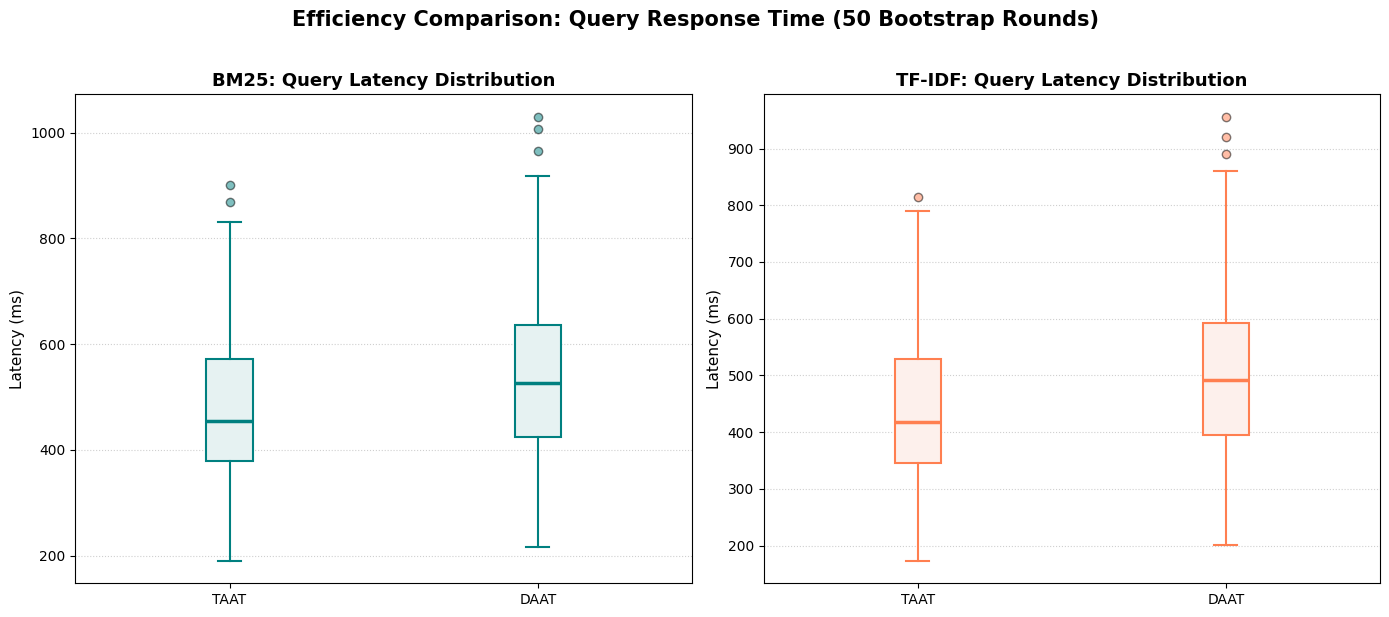

In [ ]:
# Prepare data lists for the boxplots
latency_data_bm25 = [
    np.array(bench_results["taat_bm25_lat"]) * 1000,
    np.array(bench_results["daat_bm25_lat"]) * 1000
]
latency_data_tfidf = [
    np.array(bench_results["taat_tfidf_lat"]) * 1000,
    np.array(bench_results["daat_tfidf_lat"]) * 1000
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot 1: BM25 Latency
axes[0].boxplot(latency_data_bm25, patch_artist=True, tick_labels=["TAAT", "DAAT"],
                boxprops=dict(facecolor="#e6f2f2", color="teal", linewidth=1.5),
                medianprops=dict(color="teal", linewidth=2.5),
                whiskerprops=dict(color="teal", linewidth=1.5),
                capprops=dict(color="teal", linewidth=1.5),
                flierprops=dict(marker="o", markerfacecolor="teal", alpha=0.5))
axes[0].set_title("BM25: Query Latency Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Latency (ms)", fontsize=11)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# Boxplot 2: TF-IDF Latency
axes[1].boxplot(latency_data_tfidf, patch_artist=True, tick_labels=["TAAT", "DAAT"],
                boxprops=dict(facecolor="#fdf0ec", color="coral", linewidth=1.5),
                medianprops=dict(color="coral", linewidth=2.5),
                whiskerprops=dict(color="coral", linewidth=1.5),
                capprops=dict(color="coral", linewidth=1.5),
                flierprops=dict(marker="o", markerfacecolor="coral", alpha=0.5))
axes[1].set_title("TF-IDF: Query Latency Distribution", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Latency (ms)", fontsize=11)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.suptitle("Efficiency Comparison: Query Response Time (50 Bootstrap Rounds)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

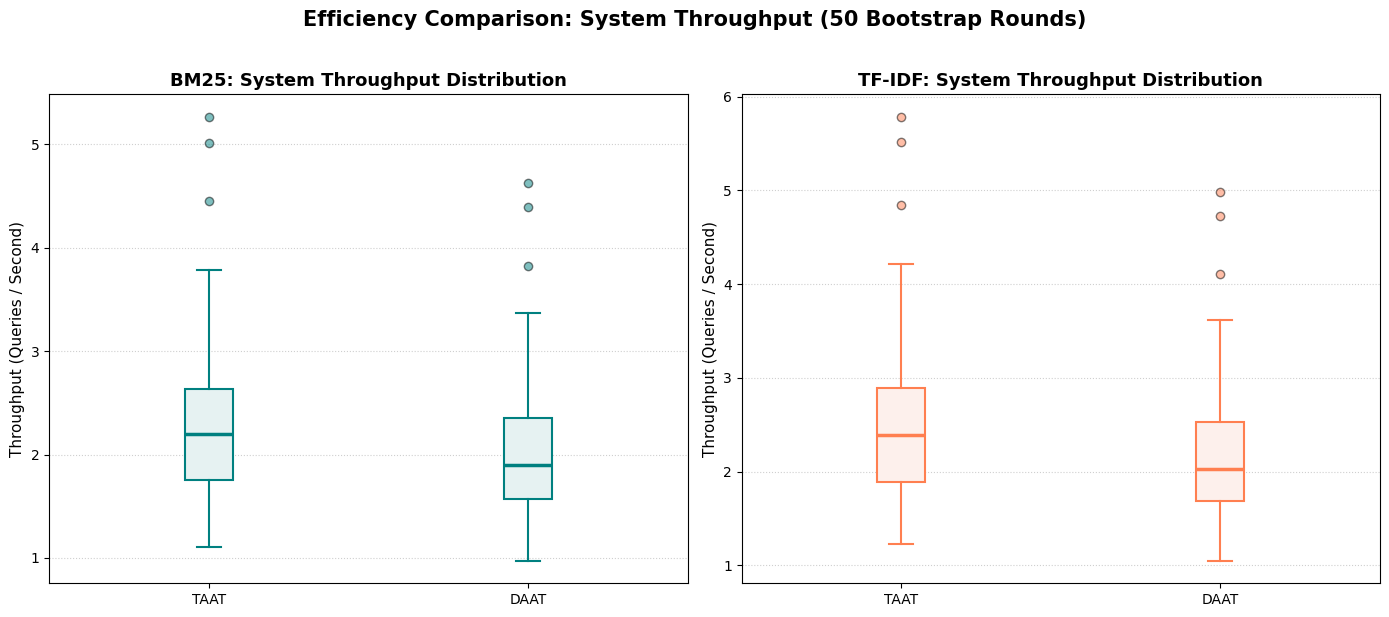

In [ ]:
# Prepare data lists for the boxplots
throughput_data_bm25 = [bench_results["taat_bm25_tp"], bench_results["daat_bm25_tp"]]
throughput_data_tfidf = [bench_results["taat_tfidf_tp"], bench_results["daat_tfidf_tp"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot 1: BM25 Throughput
axes[0].boxplot(throughput_data_bm25, patch_artist=True, tick_labels=["TAAT", "DAAT"],
                boxprops=dict(facecolor="#e6f2f2", color="teal", linewidth=1.5),
                medianprops=dict(color="teal", linewidth=2.5),
                whiskerprops=dict(color="teal", linewidth=1.5),
                capprops=dict(color="teal", linewidth=1.5),
                flierprops=dict(marker="o", markerfacecolor="teal", alpha=0.5))
axes[0].set_title("BM25: System Throughput Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Throughput (Queries / Second)", fontsize=11)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# Boxplot 2: TF-IDF Throughput
axes[1].boxplot(throughput_data_tfidf, patch_artist=True, tick_labels=["TAAT", "DAAT"],
                boxprops=dict(facecolor="#fdf0ec", color="coral", linewidth=1.5),
                medianprops=dict(color="coral", linewidth=2.5),
                whiskerprops=dict(color="coral", linewidth=1.5),
                capprops=dict(color="coral", linewidth=1.5),
                flierprops=dict(marker="o", markerfacecolor="coral", alpha=0.5))
axes[1].set_title("TF-IDF: System Throughput Distribution", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Throughput (Queries / Second)", fontsize=11)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.suptitle("Efficiency Comparison: System Throughput (50 Bootstrap Rounds)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

TAAT turns out to be the best choice, outperforming DAAT with a with a lower average query time and higher throughput. Average query time shows high variance, with values ranging from approximately 0.20 to 0.86 seconds per round. This confirms that sparse-term queries are processed quickly, whereas frequent terms generating large posting lists introduce significant bottlenecks.

Despite wide and overlapping IQRs caused by query variability, the boxplots reveal two key trends:
- **Median Shift:** The median lines of the TAAT boxplots are significantly lower (for latencies) and higher (for throughput) than their DAAT counterparts.
- **Outliers:** The upper "whiskers" of the latency plots show positive skewness. The extreme values ​​(slower rounds) penalize DAAT more severely than TAAT, suggesting that DAAT suffers more from cursor alignment on heavier queries.

The paired t-test yielded t-statistics greater than 10 and p-values ​​on the order of $10^{-20}$. This indicates that there is virtually no chance that the difference in performance is due to chance. Although DAAT is generally the standard approach in theory and industry, TAAT performs better in this specific architecture, as DAAT is optimized for larger-scale systems.

TF-IDF consistently outperforms BM25 in latency and throughput across both architectures. This is expected, since BM25 involves more computationally intensive operations, such as document-length normalization and saturation factors, which introduce measurable overhead at scale. Then we have to compare them on an Effectiveness Evaluation.

### Effectiveness Evaluation
**Effectiveness Evaluation** is the process of measuring how well a search engine or retrieval system satisfies the user's information need. It specifically quantifies the quality and accuracy of the search results.

> If you cannot measure it, you cannot improve it.

*Lord William Thompson, first Baron Kelvin (1824-1907)*


For this evaluation, we have chosen these ten statistics, so as to understand every aspect of our Information Retrieval System:
- **nDCG@10**: Rank-based metric with graded relevance. Normalizes against an ideal ranking, so scores range from 0 to 1. Strongly rewards relevant items near the top, especially highly relevant ones. Used for modern search evaluation because early ranks matter most;
- **AP / MAP**: Average Precision (AP) is the mean of precision values at each point a relevant document appears. Mean Average Precision (MAP) is AP averaged across queries. Measures overall ranking quality across the full result list. Useful as a single summary of precision and recall;
- **RR / MRR**: Reciprocal Rank (RR) is `1 / rank` of the first relevant result. Mean Reciprocal Rank (MRR) averages that over queries. Measures how fast the system finds the first correct answer. Best for QA, navigational, or "one good answer" tasks;
- **P@5**: Fraction of the top 5 results that are relevant. Measures how much useful content is immediately visible. Reflects first-page user satisfaction;
- **R@5**: Fraction of all relevant documents retrieved within the top 5. Measures how much of the available relevant set is surfaced early;
- **P(rel=2)@5**: Precision@5, but only documents with high relevance judgment (relevance score 2) count as hits. Measures how concentrated the top results are in highly relevant documents. Useful when top-tier relevance matters more than "somewhat relevant";
- **R(rel=2)@5**: Recall@5 restricted to documents with relevance score 2. Measures how many of the best answers appear in the top 5. Ignores weaker matches;
- **Bpref**: Binary Preference metric designed for incomplete judgments. It only compares the relative ranks of judged relevant documents versus judged non-relevant documents. Measures whether relevant documents rank above non-relevant ones;
- **Bpref(rel=2)**: Bpref restricted to highly relevant documents only. Measures whether the best documents outrank known non-relevant ones. Good when you want robustness plus emphasis on top-quality results;
- **Judged@10**: Percentage of the top 10 results that have explicit relevance labels. Measures how complete the ground truth is for the system's top results. High values make nDCG@10 and P@10 more trustworthy, but low values mean many results may be unjudged.

This function evaluates an Information Retrieval system by running test queries through a retriever, generating ranked document results, and comparing them against ground-truth relevance judgments (QRELs) using the `ir_measures` library. It computes and reports the set of metrics previously discussed, prints a formatted performance summary, and returns the aggregated scores for further analysis.  Since **TAAT has already been shown to outperform DAAT in terms of efficiency**, we use TAAT as the retrieval strategy to compare the effectiveness of the two scoring functions: **BM25** and **TF-IDF**.

In [ ]:
def evaluate_system_effectiveness(scorer: Any, dataset: Any, method: str = "bm25") -> Dict[Any, float]:
    """
    Evaluates the Information Retrieval system using TREC QRELs and the ir_measures framework.
    Calculates and prints the metrics in a specific, predefined order.

    Args:
        scorer (Any): The scoring instance (e.g., TAATScorer or DAATScorer).
        dataset (Any): The ir_datasets instance containing queries and relevance judgments.
        method (str, optional): The scoring method to utilize (e.g., "bm25", "tfidf"). Defaults to "bm25".

    Returns:
        Dict[Any, float]: A dictionary containing the aggregated evaluation metrics.
    """
    system_run = {}

    print(f"[*] Generating system run utilizing {method.upper()} scoring...")

    # Iterate over all queries and generate predictions
    for query in tqdm(dataset.queries_iter(), total=dataset.queries_count(), desc="Processing Queries"):
        query_id = str(query.query_id)

        # Retrieve top-k results. Scorer returns a list of (doc_id, score) tuples
        top_results = scorer.score_query(query.text, method=method)

        # Format the results for ir_measures using a dictionary comprehension
        system_run[query_id] = {str(doc_id): score for doc_id, score in top_results}

    print("[*] Calculating evaluation metrics...\n")

    # Define the exact evaluation metrics in the requested order
    evaluation_metrics = [
        nDCG@10,        # Normalized Discounted Cumulative Gain @10
        AP,             # Mean Average Precision (MAP)
        RR,             # Mean Reciprocal Rank (MRR)
        P@5,            # Precision@5
        R@5,            # Recall@5
        P(rel=2)@5,     # Precision@5 with relevance threshold 2
        R(rel=2)@5,     # Recall@5 with relevance threshold 2
        Bpref,          # Binary Preference
        Bpref(rel=2),   # Binary Preference with relevance threshold 2
        Judged@10       # Judged@10
    ]

    # Retrieve relevance judgments (QRELs)
    qrels = dataset.qrels_iter()

    # Compute aggregated scores
    aggregated_results = ir_measures.calc_aggregate(evaluation_metrics, qrels, system_run)

    # Print results directly within the function, enforcing the specific order
    print(f"======= {method.upper()} Effectiveness Results =======")
    for metric in evaluation_metrics:
        # Fallback to 0.0 if a metric couldn't be calculated
        score = aggregated_results.get(metric, 0.0)
        print(f"{str(metric)}: {score:.4f}")
    print("==========================================\n")

    return aggregated_results

taat_scorer = TAATScorer(index, k=1000)
dl2020_dataset = ir_datasets.load("msmarco-passage/trec-dl-2020/judged")

In [ ]:
taat_bm25_metrics = evaluate_system_effectiveness(
        scorer=taat_scorer,
        dataset=dl2020_dataset,
        method="bm25"
)

[*] Generating system run utilizing BM25 scoring...


Processing Queries:   0%|          | 0/54 [00:00<?, ?it/s]

[*] Calculating evaluation metrics...

======= BM25 Effectiveness Results =======
nDCG@10: 0.5011
AP: 0.3739
RR: 0.8410
P@5: 0.6444
R@5: 0.1034
P(rel=2)@5: 0.4222
R(rel=2)@5: 0.1581
Bpref: 0.4539
Bpref(rel=2): 0.2990
Judged@10: 0.9704



These results demonstrate that BM25 is a highly effective scoring function, particularly excelling in early precision and immediate document discovery.
- **High Top-Tier Quality:** A P@5 of 0.6444 and nDCG@10 of 0.5011 show the immediate results are highly dense with useful information (about 3 of the top 5 are relevant);
- **Fast First Hit:** A MRR of 0.8410 means the first relevant document almost always appears at rank 1;
- **Strict Relevance:** A P(rel=2)@5 of 0.4222 proves that nearly half of your top 5 results are highly relevant, not just loosely related;
- **Trustworthy Data:** A Judged@10 of 0.9704 guarantees these scores are highly reliable, as 97% of the top 10 retrieved documents were graded in the ground truth.

In [ ]:
taat_tfidf_metrics = evaluate_system_effectiveness(
        scorer=taat_scorer,
        dataset=dl2020_dataset,
        method="tfidf"
)

[*] Generating system run utilizing TFIDF scoring...


Processing Queries:   0%|          | 0/54 [00:00<?, ?it/s]

[*] Calculating evaluation metrics...

======= TFIDF Effectiveness Results =======
nDCG@10: 0.3598
AP: 0.2064
RR: 0.6800
P@5: 0.4852
R@5: 0.0670
P(rel=2)@5: 0.3037
R(rel=2)@5: 0.1038
Bpref: 0.3335
Bpref(rel=2): 0.2287
Judged@10: 0.8500



The TF-IDF results reveal a severe degradation in retrieval quality overall when compared to the BM25 model:
- **Collapse in Top-Tier Quality:** nDCG@10 drops from 0.5011 to 0.3598 and P@5 from 0.6444 to 0.4852, indicating far fewer relevant results at the top of the ranking;
- **Delayed First Hit:** MRR falls from 0.8410 to 0.6800, meaning users must look further down the list to find a useful document;
- **Many low-quality results:** The most telling metric is Judged@10, which dropped to 0.8500 from 0.9704. This indicates that approximately 15% of the top-10 documents retrieved by TF-IDF were not judged by human annotators. This typically occurs when the system retrieves irrelevant, obscure, or unusually long documents that a stronger retrieval system would naturally filter out;
- **Bpref Confirms the Failure:** Because so many documents were unjudged, one might wonder if the system was just "unlucky". However, Bpref (0.3335) completely ignores unjudged documents and only compares known good vs. known bad documents. Since this score is also drastically lower than BM25's (0.4537), it proves TF-IDF is objectively worse at ranking, not just suffering from missing data.

Overall, the results highlight the limitations of TF-IDF. Without BM25's term-frequency saturation and document-length normalization, TF-IDF is more sensitive to term repetition and document length, producing noisier and less accurate rankings.

### Comparison with PyTerrier
**PyTerrier** is a widely used, open-source framework for Information Retrieval research. It serves as a Python wrapper around the powerful, Java-based Terrier search engine. It provides robust, highly optimized built-in tools for loading standard datasets, accessing pre-built indexes, applying classical retrieval algorithms (like BM25 and TF-IDF), and running structured, multi-model evaluation experiments.

**Why compare against Terrier?**
* **Reliable baseline:** PyTerrier provides a validated, optimized benchmark widely used in IR research;
* **Validate custom improvements:** Comparing against PyTerrier helps quantify the impact of custom preprocessing and parameter tuning;
* **Identify weaknesses:** Performance gaps can reveal flaws or missing optimizations in custom implementations, such as length normalization or term-frequency saturation.


In [ ]:
# 1. Initialize PyTerrier (Modernized for v0.11+)
if not pt.java.started():
    pt.java.init()

print("[*] PyTerrier initialized successfully.")

# 2. Load the pre-built index for MS MARCO Passage
print("[*] Fetching the pre-built PyTerrier index for msmarco_passage...")
msmarco_dataset = pt.get_dataset("msmarco_passage")
index_ref = msmarco_dataset.get_index("terrier_stemmed")

# 3. Configure BOTH BM25 and TF-IDF retrieval models
print("[*] Configuring PyTerrier BM25 and TF-IDF retrieval models...")
pt_bm25_model = pt.terrier.Retriever(index_ref, wmodel="BM25", num_results=1000)
pt_tfidf_model = pt.terrier.Retriever(index_ref, wmodel="TF_IDF", num_results=1000)

# 4. Prepare Queries and QRELs
print("[*] Formatting queries and QRELs for the PyTerrier Experiment...")

# Function to remove punctuation that breaks the Terrier Query Parser
def clean_query(text: str) -> str:
    return re.sub(r'[^\w\s]', '', text)

# Extract and clean queries
queries_list = [{'qid': str(q.query_id), 'query': clean_query(q.text)} for q in dl2020_dataset.queries_iter()]
queries_df = pd.DataFrame(queries_list)

# Extract QRELs
qrels_list = [{'qid': str(q.query_id), 'docno': str(q.doc_id), 'label': int(q.relevance)} for q in dl2020_dataset.qrels_iter()]
qrels_df = pd.DataFrame(qrels_list)

# 5. Define the exact evaluation metrics in the strictly requested order
evaluation_metrics = [
    nDCG@10,        # Normalized Discounted Cumulative Gain @10
    AP,             # Mean Average Precision (MAP)
    RR,             # Mean Reciprocal Rank (MRR)
    P@5,            # Precision@5
    R@5,            # Recall@5
    P(rel=2)@5,     # Precision@5 with relevance threshold 2
    R(rel=2)@5,     # Recall@5 with relevance threshold 2
    Bpref,          # Binary Preference
    Bpref(rel=2),   # Binary Preference with relevance threshold 2
    Judged@10       # Judged@10
]

# 6. Execute the PyTerrier Evaluation Experiment for both models
print("[*] Running the PyTerrier Evaluation Experiment...\n")
pt_experiment_results = pt.Experiment(
    [pt_bm25_model, pt_tfidf_model],
    queries_df,
    qrels_df,
    eval_metrics=evaluation_metrics,
    names=["PyTerrier BM25", "PyTerrier TF-IDF"]
)

# Print the PyTerrier results dataframe
print("==== PyTerrier Internal Effectiveness Comparison ====")
print(pt_experiment_results.to_string(index=False))

terrier-assemblies 5.11 jar-with-dependencies not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-assemblies/5.11/terrier-assemblies-5.11-jar-with-dependenci…

Done
terrier-python-helper 0.0.8 jar not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-python-helper/0.0.8/terrier-python-helper-0.0.8.jar:   0%| …

Done


...

data.meta.idx:   0%|          | 0.00/67.5M [00:00<?, ?iB/s]

data.meta.zdata:   0%|          | 0.00/193M [00:00<?, ?iB/s]

data.properties:   0%|          | 0.00/4.29k [00:00<?, ?iB/s]

md5sums:   0%|          | 0.00/480 [00:00<?, ?iB/s]

[*] Configuring PyTerrier BM25 and TF-IDF retrieval models...
[*] Formatting queries and QRELs for the PyTerrier Experiment...
[*] Running the PyTerrier Evaluation Experiment...

==== PyTerrier Internal Effectiveness Comparison ====
            name       AP    Bpref       RR      P@5      R@5  nDCG@10  Bpref(rel=2)  P(rel=2)@5  R(rel=2)@5  Judged@10
  PyTerrier BM25 0.358724 0.447017 0.802359 0.625926 0.100599 0.493627      0.287210    0.392593     0.14799   0.972222
PyTerrier TF-IDF 0.358072 0.446573 0.802359 0.625926 0.100599 0.492575      0.287314    0.392593     0.14799   0.972222


In [ ]:
# Build the Comparative Pandas DataFrame
print("[*] Building the complete comparative DataFrame...")

# Build the rows for the custom systems, strictly respecting the metric order
custom_bm25_row = {"System": "Custom TAAT BM25"}
custom_tfidf_row = {"System": "Custom TAAT TF-IDF"}

for metric in evaluation_metrics:
    custom_bm25_row[str(metric)] = taat_bm25_metrics.get(metric, 0.0)
    custom_tfidf_row[str(metric)] = taat_tfidf_metrics.get(metric, 0.0)

# Build the rows for PyTerrier, extracting values from its experiment dataframe
pt_bm25_row = {"System": "PyTerrier BM25"}
pt_tfidf_row = {"System": "PyTerrier TF-IDF"}

for metric in evaluation_metrics:
    # Row 0 corresponds to PyTerrier BM25, Row 1 to PyTerrier TF-IDF
    pt_bm25_row[str(metric)] = pt_experiment_results.iloc[0][str(metric)]
    pt_tfidf_row[str(metric)] = pt_experiment_results.iloc[1][str(metric)]

# Combine all rows into the final comparative DataFrame
comparison_df = pd.DataFrame([custom_bm25_row, custom_tfidf_row, pt_bm25_row, pt_tfidf_row])

# Sort the DataFrame by nDCG@10 score in descending order (highest to lowest)
comparison_df = comparison_df.sort_values(by=str(nDCG@10), ascending=False)

print("\n==== Overall Effectiveness Comparison (Custom vs PyTerrier) ====")
# Print the final sorted DataFrame
print(comparison_df.to_string(index=False))

[*] Building the complete comparative DataFrame...

==== Overall Effectiveness Comparison (Custom vs PyTerrier) ====
            System  nDCG@10       AP       RR      P@5      R@5  P(rel=2)@5  R(rel=2)@5    Bpref  Bpref(rel=2)  Judged@10
  Custom TAAT BM25 0.501141 0.373905 0.841049 0.644444 0.103437    0.422222    0.158082 0.453877      0.299031   0.970370
    PyTerrier BM25 0.493627 0.358724 0.802359 0.625926 0.100599    0.392593    0.147990 0.447017      0.287210   0.972222
  PyTerrier TF-IDF 0.492575 0.358072 0.802359 0.625926 0.100599    0.392593    0.147990 0.446573      0.287314   0.972222
Custom TAAT TF-IDF 0.359805 0.206406 0.680017 0.485185 0.066983    0.303704    0.103779 0.333475      0.228747   0.850000


[*] Generating the comparative bar chart...


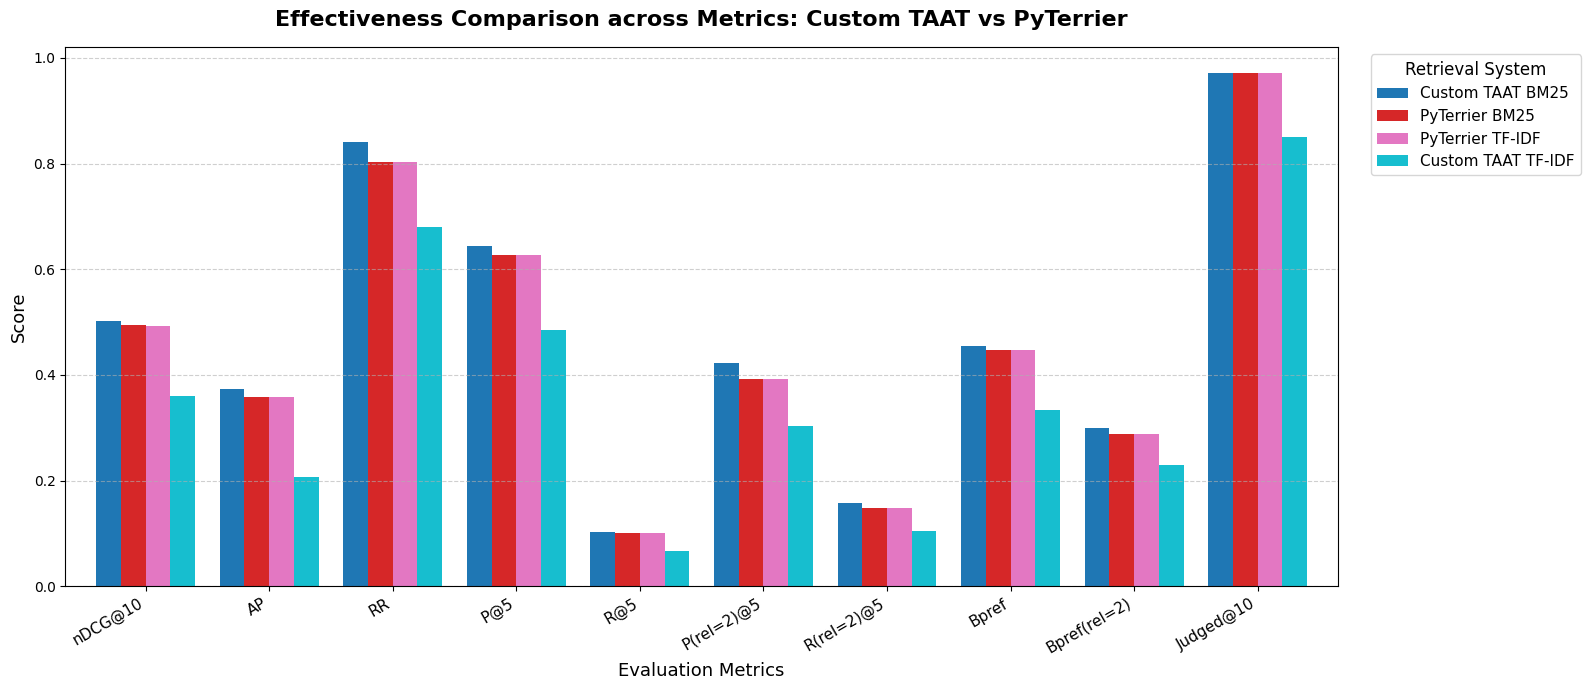

448

In [ ]:
print("[*] Generating the comparative bar chart...")

# Set the 'System' column as the index so Pandas plots the values correctly
plot_df = comparison_df.set_index("System")

# Transpose the dataframe so that Metrics are on the X-axis and Systems form the legend groups
plot_df = plot_df.T

# Generate the grouped bar chart
ax = plot_df.plot(kind='bar', figsize=(16, 7), width=0.8, colormap='tab10')

# Format the plot for better readability
plt.title("Effectiveness Comparison across Metrics: Custom TAAT vs PyTerrier", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Score", fontsize=13)
plt.xlabel("Evaluation Metrics", fontsize=13)

# Rotate x-axis labels to prevent overlap
plt.xticks(rotation=30, ha="right", fontsize=11)

# Position the legend outside the plot area
plt.legend(title="Retrieval System", title_fontsize='12', fontsize='11', bbox_to_anchor=(1.02, 1), loc='upper left')

# Add a subtle grid on the y-axis to help read values
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Remove to save RAM
del pt_experiment_results
del pt
gc.collect()

**Custom TAAT BM25** is the best-performing system across all key metrics. It completely outperforms other systems in 9 out of 10 metrics.

It achieves the highest nDCG@10 (0.5011), indicating the best ranking quality in the top results, and a strong MRR of 0.8410, meaning relevant documents are almost always ranked first. It also slightly outperforms PyTerrier BM25 in early precision (P@5: 0.6444 vs 0.6259) and strict precision (P(rel=2)@5: 0.4222 vs 0.3925). The only stat where it is slightly below PyTerrier's BM25 is percentage of the top 10 results that have explicit relevance labels, but it is by such a small amount (Judged@10: 0.9704 vs 0.9722) that they can be considered equal.

Overall, this confirms that custom preprocessing and choosing optimal hyperparameters provide a measurable improvement over the baseline implementation.


An interesting anomaly in the data is the near-identical performance of PyTerrier BM25 and PyTerrier TF-IDF. In pure theory, BM25 should vastly outperform TF-IDF. Furthermore, our TF-IDF is extremely far from the effectiveness of PyTerrier's TF-IDF.

Reading [PyTerrier Documentation](https://pyterrier.readthedocs.io/en/latest/terrier/api.html), we find that TF-IDF uses Robertson's Term Frequency implementation, the same one used by BM25, while IDF's implementation remains Sparck Jones's.

$$\text{TF}_{\text{norm}}(t, d) = \frac{\text{tf}_{t,d} \cdot (k_1 + 1)}{\text{tf}_{t,d} + k_1 \cdot \left( 1 - b + b \cdot \frac{\text{len}(d)}{\text{avgdl}} \right)}$$

$$\text{IDF}(t) = \log_2 \left( \frac{N}{n_t} \right)$$

$$\text{TF-IDF}_{\text{Terrier}}(t, d) = \text{TF}_{\text{norm}}(t, d) \cdot \text{IDF}(t)$$

Consequently, since our implementation more closely follows the classical formulation (using BM25-style IDF rather than the Sparck Jones variant, and standard term frequency), the observed performance difference between our TF-IDF and PyTerrier's implementation is unlikely to be due to implementation errors on our side. Instead, it is attributable to PyTerrier's use of normalized term frequency. This also explains the similarity in performance with BM25.



## Conclusions

### Summary
The notebook outlines the creation of an Information Retrieval system using the MS MARCO dataset. It details the text preprocessing pipeline (lowercasing, normalization, URL/acronym extraction, and fast Cython-based stemming via PyStemmer). It covers the creation of an inverted index and its memory optimization using SIMD-accelerated FastPFor compression (PForDelta for DocIDs, PFor for frequencies). Query processing is implemented using two strategies: Term-At-A-Time (TAAT) and Document-At-A-Time (DAAT), supported by Min-Heaps (TopQueue) for top-k extraction. Finally, the system is rigorously evaluated against TREC 2020 Deep Learning queries using ir_measures and benchmarked for efficiency (latency and throughput).

### Search Engine
The SearchEngine class acts as the central orchestrator for the interactive retrieval phase, cleanly encapsulating the compiled inverted index and the ir_datasets collection. During initialization, it automatically iterates through the dataset to construct an internal, in-memory dictionary (doc_lookup) that maps document IDs directly to their raw textual content. The engine is configured to strictly utilize a Term-at-a-Time (TAAT) processing architecture, driven by a TAATScorer initialized to retrieve the top 10 documents using the optimally tuned BM25 parameters identified during the project ($k_1 = 0.82$ and $b = 0.68$).

In [ ]:
class SearchEngine:
    """
    SearchEngine class that encapsulates the inverted index, automatically
    builds a document lookup from an ir_datasets object, and runs
    interactive queries using TAAT and BM25 scoring.
    """
    def __init__(self, index, dataset):
        """
        Initializes the Search Engine, builds the internal document lookup from the dataset,
        and sets up the TAATScorer with BM25 parameters.

        Args:
            index (InvertedIndex): The compiled inverted index structure.
            dataset: The ir_datasets object (e.g., dl2020_dataset) containing MS MARCO passages.
        """
        self.index = index
        self.doc_lookup = {}

        print("[*] Initializing Search Engine... ")
        print("[*] Building internal document lookup from dataset... Please wait.")
        # Iterate over the dataset collection to populate the local lookup dictionary
        # Mapping original doc_id (as string) to its corresponding text content
        for doc in dataset.docs_iter():
            self.doc_lookup[str(doc.doc_id)] = doc.text

        print(f"[*] Lookup built successfully with {len(self.doc_lookup)} documents.")

        # Initialize the TAAT Scorer with the optimal BM25 parameters found in the project
        self.scorer = TAATScorer(self.index, k=10, bm25_k1=0.82, bm25_b=0.68)
        print("[*] Using a TAAT Query Processing approach.")
        print("[*] BM25 as a Scoring Function: optimal parameters: k1=0.82, b=0.68.")
        print("[*] Search Engine initialized successfully.")

    @profile
    def _start_search(self, user_query: str):
        """
        Executes the search pipeline for a query and displays the top results.

        Separates scoring and rendering logic from user input, allowing `@profile`
        to accurately measure TAAT processing and BM25 scoring without including
        `input()` I/O time.

        Args:
            user_query (str): The string query to be evaluated by the search engine.
        """
        # Compute BM25 scores using the pre-existing TAAT framework
        results = self.scorer.score_query(user_query, method="bm25")

        print("\nTop 10 results:")
        print("-" * 50)

        # score_query returns a list of tuples: (doc_id, score) sorted by relevance
        for rank, (doc_id, score) in enumerate(results, start=1):
            print(f"Rank {rank} | Document ID: {doc_id} (Score: {score:.4f})")

            # Fetch the raw text using the internally constructed lookup
            doc_text = self.doc_lookup.get(str(doc_id))

            if doc_text:
                # Truncate long snippets for a clean console visualization
                snippet = doc_text[:150] + "..." if len(doc_text) > 150 else doc_text
                print(f"Text: {snippet}\n")
            else:
                print(f"Document text not found in the local lookup structure.\n")

    def search(self):
        """
        Interactively prompts the user for a query and displays the top 10 results
        using the internal TAAT Scorer and document lookup.
        """
        user_query = input("Enter your search query: ")
        print(f"\nSearching for: '{user_query}'...")
        self._start_search(user_query)

search_engine = SearchEngine(index, dl2020_dataset)

[*] Initializing Search Engine... 
[*] Building internal document lookup from dataset... Please wait.
[*] Lookup built successfully with 8841823 documents.
[*] Using a TAAT Query Processing approach.
[*] BM25 as a Scoring Function: optimal parameters: k1=0.82, b=0.68.
[*] Search Engine initialized successfully.


In [ ]:
search_engine.search()

Enter your search query: What is Information Retrieval?

Searching for: 'What is Information Retrieval?'...

Top 10 results:
--------------------------------------------------
Rank 1 | Document ID: 2502427 (Score: 22.6614)
Text: Semantic information retrieval method have exploited the advantages of the semantic web to retrieve the relevant data. It outperforms VSM, the classic...

Rank 2 | Document ID: 8623714 (Score: 22.0173)
Text: information retrieval. The technique and process of searching, recovering, and interpreting information from large amounts of stored data. Information...

Rank 3 | Document ID: 1361665 (Score: 21.8323)
Text: Retrieval. The last step in forming episodic memories is called retrieval, which is the conscious recollection of information that was encoded. Retrie...

Rank 4 | Document ID: 4192974 (Score: 21.6286)
Text: “Retrieval practice” is a learning strategy where we focus on getting information out. Through the act of retrieval, or calling information to mind

### Future Improvements
To overcome the inherent limitations of exact keyword matching and build upon the robust lexical foundation, future iterations of the search engine will focus on the following enhancements:

- **Learning-to-Rank (LTR) with LambdaMART:** Implementing a gradient-boosted decision tree to re-rank the initial top candidates retrieved by the BM25 model, allowing the system to calculate final relevance scores using a rich combination of structural features and statistical baselines without losing latency;
- **Deep Learning Semantic Re-ranking (BERT):** Integrating a BERT-based Cross-Encoder to deeply analyze the top-100 lexical hits by feeding the query and passage simultaneously into the model, which captures deep contextual relationships and effectively solves the vocabulary mismatch problem (e.g., matching "car" to "automobile");
- **Parallelization of build_index:** Implementing multi-threaded or distributed document processing to allow concurrent indexing across multiple shards, significantly reducing the total time required to build or refresh the inverted index;
- **Pseudo-Relevance Feedback (PRF) and Query Expansion:** Incorporating techniques like the RM3 model or Rocchio algorithm to automatically expand the user's initial search with highly relevant terms extracted from the first pass of top-ranked documents, significantly improving the system's overall recall;
- **Query Autocorrection and Preprocessing:** Adding a robust user-intent module featuring probabilistic spelling correction (using edit-distance algorithms or character-level n-grams) to gracefully handle user typos, preventing zero-result pages before the core search pipeline is even triggered.

### Results
The evaluation phase clearly confirms the success and reliability of the custom IR pipeline.

Our Search Engine achieved excellent ranking quality, securing an nDCG@10 of 0.5011, a MAP of 0.3739, and an MRR of 0.8410. This performance successfully matched and slightly outperformed the established PyTerrier BM25 baseline (nDCG@10 of 0.4936, a MAP of 0.3587, and an MRR of 0.8024).

On the computational efficiency front, we have seen how our Search Engine is able to respond to a query in an average of 483.76 ms (Standard Deviation: 169.07 ms), thus confirming excellent response times.

Ultimately, the project demonstrates that integrating foundational IR principles with aggressive memory management, SIMD compression, and C-level optimizations yields a highly scalable and effective Search Engine.